# VAF associated to mutations from duplex seq: 
# pseudocounting vs hierarchical estimation

In [1]:
import glob
import pandas as pd
import seaborn as sns

#import arviz as az
#import arviz_plots as azp
#import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from pathlib import Path
from scipy.stats import binom
from scipy.stats import beta
from scipy.stats import beta as beta_dist
from scipy.optimize import minimize_scalar


from pandas.api.types import is_numeric_dtype

## Helpers

In [2]:
def plot_scatter_with_diagonal(
    df,
    x_col,
    y_col,
    log_scale_x=True,
    log_scale_y=True,
    alpha=1,
    s=2,
    figsize=(5, 3),
    color_col=None,
    plot_diag=True,
    extra_lines=None,
    scatter_color=None,  # single color when color_col is None, e.g. 'blue', '#ff0000'
    cmap='viridis',       # colormap for numeric color_col
    norm=None,
    xlim=None,  # e.g. (0, 100)
    ylim=None   # e.g. (-5, 5)
):
    cols = [x_col, y_col] + ([color_col] if color_col else [])
    plot_df = df[cols].dropna().copy()
    if log_scale_x:
        plot_df = plot_df[plot_df[x_col] > 0]
    if log_scale_y:
        plot_df = plot_df[plot_df[y_col] > 0]
    plt.figure(figsize=figsize)
    if color_col is None:
        plt.scatter(
            plot_df[x_col],
            plot_df[y_col],
            alpha=alpha,
            s=s,
            color=scatter_color,
            norm=norm
        )
    elif is_numeric_dtype(plot_df[color_col]):
        sc = plt.scatter(
            plot_df[x_col],
            plot_df[y_col],
            c=plot_df[color_col],
            alpha=alpha,
            s=s,
            cmap=cmap,
            norm=norm
        )
        plt.colorbar(sc, label=color_col)
    else:
        for value, sub_df in plot_df.groupby(color_col):
            plt.scatter(
                sub_df[x_col],
                sub_df[y_col],
                alpha=alpha,
                s=s,
                label=str(value)
            )
        plt.legend(title=color_col)
    lims = [
        min(plot_df[x_col].min(), plot_df[y_col].min()),
        max(plot_df[x_col].max(), plot_df[y_col].max())
    ]
    if plot_diag:
        plt.plot(lims, lims, 'r--', lw=1, label='1:1')
        plt.xlim(lims)
        plt.ylim(lims)
    if extra_lines:
        for line in extra_lines:
            plt.plot(
                line['x'],
                line['y'],
                color=line.get('color', 'red'),
                linestyle=line.get('linestyle', '--'),
                linewidth=line.get('linewidth', 1.5),
                label=line.get('label', '')
            )
        plt.legend()
    if log_scale_x:
        plt.xscale('log')
    if log_scale_y:
        plt.yscale('log')
    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)        
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

In [3]:
def plot_facet_scatter(
    df,
    x,
    y,
    facet_col="MUTATION",
    hue="DEPTH",
    col_wrap=6,
    log_x=True,
    log_y=True,
    add_diagonal=True,
    palette="viridis",
    alpha=0.7,
    height=3,
    aspect=1,
    sharex=False,
    sharey=False,
):
    """
    Faceted scatter plot with optional log scales and y=x diagonal.
    """

    g = sns.relplot(
        data=df,
        x=x,
        y=y,
        col=facet_col,
        hue=hue,
        kind="scatter",
        palette=palette,
        alpha=alpha,
        height=height,
        aspect=aspect,
        col_wrap=col_wrap,
        facet_kws={
            "sharex": sharex,
            "sharey": sharey,
        },
    )

    for ax in g.axes.flat:

        if log_x:
            ax.set_xscale("log")

        if log_y:
            ax.set_yscale("log")

        if add_diagonal:

            xmin, xmax = ax.get_xlim()
            ymin, ymax = ax.get_ylim()

            lo = max(min(xmin, ymin), 1e-10)
            hi = min(max(xmax, ymax), 1)

            ax.plot(
                [lo, hi],
                [lo, hi],
                color="black",
                linestyle="--",
                linewidth=1,
                zorder=0,
            )

    g.set_axis_labels(x, y)

    return g

In [4]:
def joint_log_likelihood(p, alt_d, depth_d, alt_nd, depth_nd, e_nd=1e-4):
    # Duplex: error rate so low we ignore it
    ll_duplex = binom.logpmf(alt_d, depth_d, p)
    # Non-duplex: observed alt could be real variant OR error
    p_nd_effective = p + (1 - p) * e_nd  # P(see alt | true VAF = p)
    ll_nd = binom.logpmf(alt_nd, depth_nd, p_nd_effective)
    return -(ll_duplex + ll_nd)  # negative for minimization

def estimate_vaf(row, e_nd=1e-4):
    res = minimize_scalar(
        joint_log_likelihood,
        bounds=(1e-9, 1),
        method='bounded',
        args=(row['ALT_DEPTH'], row['DEPTH'],
              row['ALT_DEPTH_ND'], row['DEPTH_ND'], e_nd)
    )
    return res.x



In [5]:
def get_mutations(time):

    #df = pd.read_csv(f'{fn}/Timepoint{time}.somatic.mutations.tsv', sep='\t', low_memory=False)
    df = pd.read_csv(f'{fn}/all_samples.somatic.mutations.tsv', sep='\t', low_memory=False)
    df['MUTATION_ID'] = df['CHROM'] + ':' + df['POS'].astype(str) + ':' + df['REF'] + '>' + df['ALT']
    df['INDIVIDUAL_ID'] = df['SAMPLE_ID'].str.split('_').str[:2].str.join('_')
    dg = df[['MUTATION_ID', 'INDIVIDUAL_ID', 'SAMPLE_ID', 'DEPTH', 'DEPTH_AM', 'ALT_DEPTH', 'ALT_DEPTH_AM','DEPTH_ND','ALT_DEPTH_ND','SYMBOL','TYPE','Consequence',"Protein_affecting","FILTER.not_in_exons"]]
    # exclude mutations in pediatric individuals
    dg = dg[~dg['INDIVIDUAL_ID'].str.contains('CHp')]
    return dg

def get_mutations_from_samples(time):

    df = pd.read_csv(f'{fn}/Timepoint{time}.somatic.mutations.tsv', sep='\t', low_memory=False)
    df['MUTATION_ID'] = df['CHROM'] + ':' + df['POS'].astype(str) + ':' + df['REF'] + '>' + df['ALT']
    df['INDIVIDUAL_ID'] = df['SAMPLE_ID'].str.split('_').str[:2].str.join('_')
    dg = df[['MUTATION_ID', 'INDIVIDUAL_ID', 'SAMPLE_ID', 'DEPTH', 'DEPTH_AM', 'ALT_DEPTH', 'ALT_DEPTH_AM','SYMBOL','TYPE','Consequence',"Protein_affecting"]]
    # exclude mutations in pediatric individuals
    dg = dg[~dg['INDIVIDUAL_ID'].str.contains('CHp')]
    for id, sub_dg in df.groupby('INDIVIDUAL_ID'):
        yield id, sub_dg

In [6]:
def collect_syn_depths_for_samples(
    samples,
    depth_dir,
    syn_panel_df,
    merge_cols=("CHROM", "POS", "REF", "ALT"),
    depth_suffix=".depths.annotated.tsv.gz",
):
    depth_dir = Path(depth_dir)
    all_sample_depths = []

    for sample in samples:
        depth_path = depth_dir / f"{sample}{depth_suffix}"

        if not depth_path.exists():
            print(f"Missing file: {depth_path}")
            continue

        df_depth = pd.read_csv(depth_path, sep="\t")

        df_depth_syn = df_syn_panel.merge(df_depth,on=["CHROM", "POS"], how="left")
        df_depth_syn = df_depth_syn.rename(columns={sample: "DEPTH"})
        df_depth_syn["SAMPLE_ID"] = sample

        all_sample_depths.append(df_depth_syn)

    if len(all_sample_depths) == 0:
        return pd.DataFrame()

    return pd.concat(all_sample_depths, ignore_index=True)

## Define deepCSA folder

In [7]:
#deepCSA_dir = '/data/bbg/nobackup/prominent/chip/folders_for_review/2026-01-20_CHa_I_T0s_custom_plus_hotspots/'
#deepCSA_dir = '/data/bbg/nobackup/prominent/kidney/deepCSA/LCMs/2026-04-27_cleaner_samples_full_run/'
deepCSA_dir = '/data/bbg/nobackup/bladder_ts/results/2026-03-26_deepCSA_upd_outputs/'
#deepCSA_dir = '/data/bbg/nobackup/prominent/pancreas/deepcsa/2026-05-19_pancreas_pilot2'

#metadata_file = '/data/bbg/nobackup/prominent/chip/deepCSA/inputs_features/deepCSA_2026-04-14_CH_I_wSP_features.tsv'
#metadata_file = '/data/bbg/datasets/prominent/metadata/pancreas/data/pilot2/2026-04-19.parsed_metadata.pilot2.tsv'


In [8]:
#metadata = pd.read_csv(metadata_file, sep='\t')
#metadata.head()

In [9]:
#metadata.loc[(metadata['INDIVIDUAL_ID'] == 'SP001') & (metadata['TIMEPOINT'] == 'T0'), 'SEX'].values[0]

In [10]:
fn = deepCSA_dir + '/mutations/clean_somatic/'
for f in glob.glob(fn + '/T*.somatic.mutations.tsv'):
    print(f)

## Download mutations

In [11]:
dg = get_mutations('T0')
dg["MUTATION"] = dg["MUTATION_ID"].str.split(":").str[-1]
dg.head()

,MUTATION_ID,INDIVIDUAL_ID,SAMPLE_ID,DEPTH,DEPTH_AM,ALT_DEPTH,ALT_DEPTH_AM,DEPTH_ND,ALT_DEPTH_ND,SYMBOL,TYPE,Consequence,Protein_affecting,FILTER.not_in_exons,MUTATION
0,chr1:26729450:T>C,P19_0024,P19_0024_BTR_01,930,1817,1,1,887,0,ARID1A,SNV,5_prime_UTR_variant,non_protein_affecting,True,T>C
1,chr1:26729474:TAG>T,P19_0014,P19_0014_BDO_01,1470,4192,1,2,2722,1,ARID1A,DELETION,5_prime_UTR_variant,non_protein_affecting,True,TAG>T
2,chr1:26729479:TTC>T,P19_0023,P19_0023_BDO_01,1961,3305,1,1,1344,0,ARID1A,DELETION,5_prime_UTR_variant,non_protein_affecting,True,TTC>T
3,chr1:26729563:G>C,P19_0023,P19_0023_BDO_01,3490,5847,1,1,2357,0,ARID1A,SNV,5_prime_UTR_variant,non_protein_affecting,True,G>C
4,chr1:26729566:TA>T,P19_0040,P19_0040_BTR_01,2114,5011,1,3,2897,2,ARID1A,DELETION,5_prime_UTR_variant,non_protein_affecting,True,TA>T


In [12]:
dg.columns

Index(['MUTATION_ID', 'INDIVIDUAL_ID', 'SAMPLE_ID', 'DEPTH', 'DEPTH_AM',
       'ALT_DEPTH', 'ALT_DEPTH_AM', 'DEPTH_ND', 'ALT_DEPTH_ND', 'SYMBOL',
       'TYPE', 'Consequence', 'Protein_affecting', 'FILTER.not_in_exons',
       'MUTATION'],
      dtype='object')

In [13]:
print(dg['DEPTH'].mean())
print(dg['DEPTH_ND'].mean())

6193.242657125078
5929.236636589919


In [14]:
dg['ALT_DEPTH_AM'].sum()/dg['DEPTH_AM'].sum()

np.float64(0.00018999837775087773)

In [15]:
avail_samples = dg["SAMPLE_ID"].unique()
dg = dg[dg["ALT_DEPTH_AM"] >= dg["ALT_DEPTH"]]

## Collect syn depth per sample

In [16]:
df_syn_panel = pd.read_csv(deepCSA_dir + "/regions/consensuspanels/consensus.synonymous.tsv", sep="\t")
df_syn_panel = df_syn_panel[["CHROM", "POS"]].drop_duplicates()
print(df_syn_panel.shape)
df_syn_panel.head()

(22593, 2)


,CHROM,POS
0,chr1,26729656
3,chr1,26729659
4,chr1,26729662
7,chr1,26729668
8,chr1,26729671


In [17]:
df_depth_syn_all = collect_syn_depths_for_samples(
    samples=avail_samples,
    depth_dir=deepCSA_dir + "/depths/individual/",
    syn_panel_df=df_syn_panel,
    merge_cols=["CHROM", "POS"]
)


In [18]:
df_depth_syn_all.head()

,CHROM,POS,CONTEXT,DEPTH,SAMPLE_ID
0,chr1,26729656,CCA,4467,P19_0024_BTR_01
1,chr1,26729659,GTC,4450,P19_0024_BTR_01
2,chr1,26729662,TTG,4490,P19_0024_BTR_01
3,chr1,26729668,ATC,4519,P19_0024_BTR_01
4,chr1,26729671,TCT,4576,P19_0024_BTR_01


In [19]:
print(dg.shape)
print(dg[dg['ALT_DEPTH_ND']==0].shape)

(63930, 15)
(48520, 15)


In [20]:
df_mean_depth = (
    df_depth_syn_all.groupby('SAMPLE_ID')[['DEPTH']]
      .mean()
      .reset_index()
)
df_mean_depth.head()

,SAMPLE_ID,DEPTH
0,P19_0001_BDO_01,5266.002479
1,P19_0001_BTR_01,5737.695127
2,P19_0002_BDO_01,4062.286947
3,P19_0002_BTR_01,3976.501925
4,P19_0003_BDO_01,5864.779002


## Computing priors

In [21]:
def collect_mutdensities_for_samples(
    samples,
    mutdensity_dir,
):
    mutdensity_dir = Path(mutdensity_dir)
    all_sample_mutdensity = []

    for sample in samples:
        mutdensity_NPA_path = mutdensity_dir / f"{sample}.non_protein_affecting.mutdensities.tsv"
        mutdensity_PA_path = mutdensity_dir / f"{sample}.protein_affecting.mutdensities.tsv"

        if not mutdensity_NPA_path.exists():
            print(f"Missing file: {mutdensity_NPA_path}")
            continue
        if not mutdensity_PA_path.exists():
            print(f"Missing file: {mutdensity_PA_path}")
            continue

        df_mutdensity_NPA = pd.read_csv(mutdensity_NPA_path, sep="\t")
        df_mutdensity_NPA = df_mutdensity_NPA[(df_mutdensity_NPA["GENE"] == "ALL_GENES") & (df_mutdensity_NPA["MUTTYPES"] == "all_types")]
        df_mutdensity_NPA = df_mutdensity_NPA[["SAMPLE_ID", "REGIONS", "N_MUTATED", "DEPTH"]]
        df_mutdensity_PA = pd.read_csv(mutdensity_PA_path, sep="\t")
        df_mutdensity_PA = df_mutdensity_PA[(df_mutdensity_PA["GENE"] == "ALL_GENES") & (df_mutdensity_PA["MUTTYPES"] == "all_types")]
        df_mutdensity_PA = df_mutdensity_PA[["SAMPLE_ID", "REGIONS", "N_MUTATED", "DEPTH"]]
        all_sample_mutdensity.append(df_mutdensity_NPA)
        all_sample_mutdensity.append(df_mutdensity_PA)

    if len(all_sample_mutdensity) == 0:
        return pd.DataFrame()

    return pd.concat(all_sample_mutdensity, ignore_index=True)

In [22]:
avail_samples_with_all = np.append(avail_samples, "all_samples")
avail_samples_with_all

array(['P19_0024_BTR_01', 'P19_0014_BDO_01', 'P19_0023_BDO_01',
       'P19_0040_BTR_01', 'P19_0002_BTR_01', 'P19_0035_BDO_01',
       'P19_0023_BTR_01', 'P19_0011_BDO_01', 'P19_0041_BDO_01',
       'P19_0042_BDO_01', 'P19_0024_BDO_01', 'P19_0046_BDO_01',
       'P19_0046_BTR_01', 'P19_0038_BDO_01', 'P19_0051_BTR_01',
       'P19_0050_BDO_01', 'P19_0033_BDO_01', 'P19_0043_BTR_01',
       'P19_0050_BTR_01', 'P19_0029_BTR_01', 'P19_0008_BDO_01',
       'P19_0051_BDO_01', 'P19_0020_BDO_01', 'P19_0014_BTR_01',
       'P19_0004_BDO_01', 'P19_0001_BTR_01', 'P19_0012_BDO_01',
       'P19_0039_BTR_01', 'P19_0028_BTR_01', 'P19_0040_BDO_01',
       'P19_0008_BTR_01', 'P19_0053_BDO_01', 'P19_0028_BDO_01',
       'P19_0047_BTR_01', 'P19_0016_BDO_01', 'P19_0016_BTR_01',
       'P19_0018_BTR_01', 'P19_0005_BTR_01', 'P19_0009_BTR_01',
       'P19_0018_BDO_01', 'P19_0002_BDO_01', 'P19_0007_BTR_01',
       'P19_0045_BTR_01', 'P19_0029_BDO_01', 'P19_0031_BTR_01',
       'P19_0019_BDO_01', 'P19_0047_BDO_

In [23]:
df_mutdensities_all = collect_mutdensities_for_samples(
    samples=avail_samples_with_all,
    mutdensity_dir=deepCSA_dir + "/mutdensity/individual_vals",
)

In [24]:
df_mutdensities_all.head()

,SAMPLE_ID,REGIONS,N_MUTATED,DEPTH
0,P19_0024_BTR_01,non_protein_affecting,158.0,435471257
1,P19_0024_BTR_01,protein_affecting,219.0,321942209
2,P19_0014_BDO_01,non_protein_affecting,236.0,417659809
3,P19_0014_BDO_01,protein_affecting,681.0,353203774
4,P19_0023_BDO_01,non_protein_affecting,521.0,434015164


In [25]:
df_mutdensities_all['prior'] = df_mutdensities_all['N_MUTATED']/df_mutdensities_all['DEPTH']
df_mutdensities_all

,SAMPLE_ID,REGIONS,N_MUTATED,DEPTH,prior
0,P19_0024_BTR_01,non_protein_affecting,158.0,435471257,3.628253e-07
1,P19_0024_BTR_01,protein_affecting,219.0,321942209,6.802463e-07
2,P19_0014_BDO_01,non_protein_affecting,236.0,417659809,5.650532e-07
3,P19_0014_BDO_01,protein_affecting,681.0,353203774,1.928065e-06
4,P19_0023_BDO_01,non_protein_affecting,521.0,434015164,1.200419e-06
...,...,...,...,...,...
155,P19_0041_BTR_01,protein_affecting,388.0,187852286,2.065453e-06
156,P19_0036_BTR_01,non_protein_affecting,17.0,76500585,2.222205e-07
157,P19_0036_BTR_01,protein_affecting,10.0,70124925,1.426026e-07
158,all_samples,non_protein_affecting,15922.0,29391215066,5.417265e-07


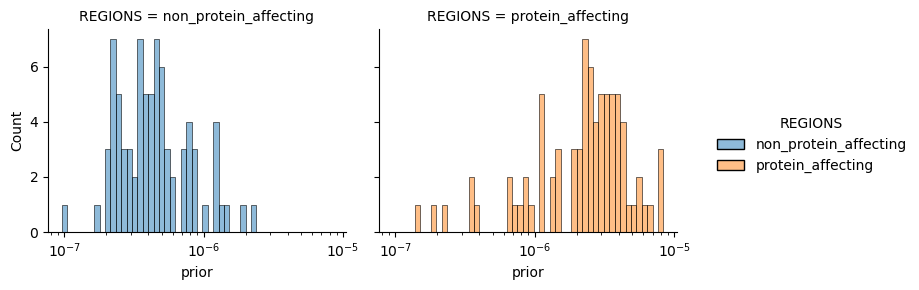

In [26]:
import seaborn as sns

sns.displot(
    data=df_mutdensities_all[df_mutdensities_all["SAMPLE_ID"]!="all_samples"],
    x="prior",
    col="REGIONS",      # facets
    hue="REGIONS",      # color
    bins=50,
    height=3,
    aspect=1.2,    
    log_scale=True

)

In [27]:
df_mutdensities_all_wide = (
    df_mutdensities_all[df_mutdensities_all["SAMPLE_ID"]!="all_samples"].pivot(
        index="SAMPLE_ID",
        columns="REGIONS",
        values="prior"
    )
    .reset_index()
)
df_mutdensities_all_wide.head()

REGIONS,SAMPLE_ID,non_protein_affecting,protein_affecting
0,P19_0001_BDO_01,9.593073e-08,3.748162e-07
1,P19_0001_BTR_01,1.995180e-07,8.297392e-07
2,P19_0002_BDO_01,1.249675e-06,4.721269e-06
3,P19_0002_BTR_01,1.316807e-06,4.144133e-06
4,P19_0003_BDO_01,5.177079e-07,3.170660e-06


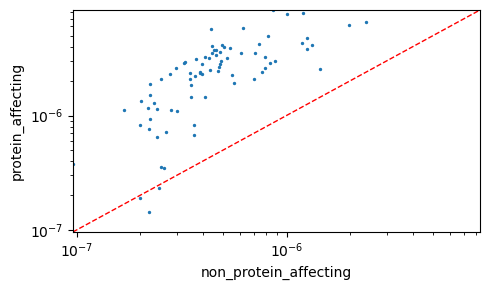

In [28]:
plot_scatter_with_diagonal(df_mutdensities_all_wide,'non_protein_affecting','protein_affecting',log_scale_x=True,log_scale_y=True)

In [29]:
df_mutdensities_all_wide['non_protein_affecting'].mean()

np.float64(5.377051565092059e-07)

### VAF plots

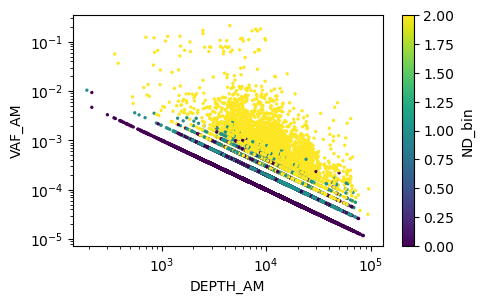

In [30]:
# plot duplex VAF

dg['VAF'] = dg['ALT_DEPTH'] / dg['DEPTH']
dg['VAF_AM'] = dg['ALT_DEPTH_AM'] / dg['DEPTH_AM']
dg['VAF_ND'] = dg['ALT_DEPTH_ND'] / dg['DEPTH_ND']
#dg["ND_bin"] = np.where(dg["ALT_DEPTH_ND"] == 0, 0, 1)
dg["ND_bin"] = np.where(
    dg["ALT_DEPTH_ND"] == 0,
    0,
    np.where(dg["ALT_DEPTH_ND"] == 1, 1, 2)
)

plt.figure(figsize=(5, 3))
sc = plt.scatter(dg['DEPTH_AM'], dg['VAF_AM'], c=dg['ND_bin'].astype(int), s=2)
plt.xlabel('DEPTH_AM')
plt.ylabel('VAF_AM')
plt.yscale('log')
plt.xscale('log')
plt.colorbar(sc, label="ND_bin")
plt.show()

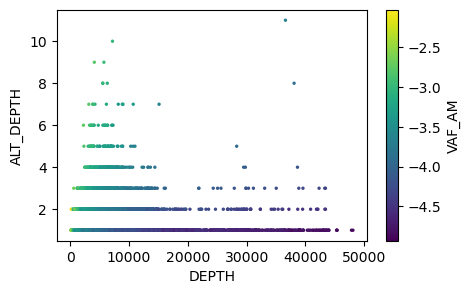

In [31]:
dg_ND_zero = dg[dg['ALT_DEPTH_ND']==0]
plt.figure(figsize=(5, 3))
s1 = plt.scatter(dg_ND_zero['DEPTH'], dg_ND_zero['ALT_DEPTH'], s=2, c=np.log10(dg_ND_zero['VAF_AM']))
plt.xlabel('DEPTH')
plt.ylabel('ALT_DEPTH')
#plt.yscale('log')
#plt.xscale('log')
plt.colorbar(s1, label="VAF_AM")
plt.show()

In [32]:
dg_ND_zero[dg_ND_zero["ALT_DEPTH"]>=10]

,MUTATION_ID,INDIVIDUAL_ID,SAMPLE_ID,DEPTH,DEPTH_AM,ALT_DEPTH,ALT_DEPTH_AM,DEPTH_ND,ALT_DEPTH_ND,SYMBOL,TYPE,Consequence,Protein_affecting,FILTER.not_in_exons,MUTATION,VAF,VAF_AM,VAF_ND,ND_bin
3649,chr1:26772870:C>T,P19_0023,P19_0023_BDO_01,7180,10229,10,10,3049,0,ARID1A,SNV,stop_gained,protein_affecting,False,C>T,0.001393,0.000978,0.0,0
43419,chr6:1313138:TCAA>T,P19_0031,P19_0031_BTR_01,36590,49958,11,11,13368,0,FOXQ1,DELETION,inframe_deletion,protein_affecting,False,TCAA>T,0.000301,0.000220,0.0,0


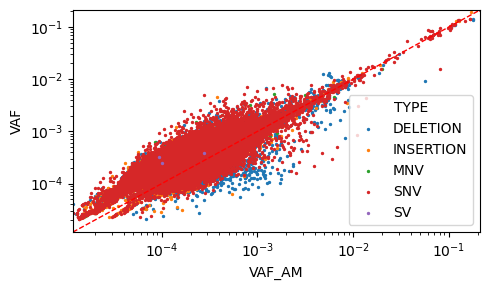

In [33]:
plot_scatter_with_diagonal(dg,'VAF_AM','VAF',color_col='TYPE')

In [34]:
def vaf_pseudocount(alt_depth, depth, weight, prior_vaf=None):
    
    return (alt_depth + prior_vaf * weight) / (depth + weight)

In [35]:
def vaf_pseudocount_nd(alt_depth, depth, weight, prior_vaf=None):
    
    return (alt_depth + prior_vaf * weight) / (depth + weight)

In [36]:
def vaf_lower_bound(alt_depth, depth, alpha=0.05):
    return beta.ppf(
        alpha,
        alt_depth ,
        depth - alt_depth
    )

In [37]:
def vaf_beta_bounds(alt_depth, depth, alpha=0.05):
    lower = beta.ppf(
        alpha / 2,
        alt_depth + 1,
        depth - alt_depth + 1
    )

    upper = beta.ppf(
        1 - alpha / 2,
        alt_depth + 1,
        depth - alt_depth + 1
    )

    return lower, upper

In [38]:
dg["VAF_LB95"] = vaf_lower_bound(
    dg["ALT_DEPTH_AM"],
    dg["DEPTH_AM"]
)

In [39]:
dg.head()

,MUTATION_ID,INDIVIDUAL_ID,SAMPLE_ID,DEPTH,DEPTH_AM,ALT_DEPTH,ALT_DEPTH_AM,DEPTH_ND,ALT_DEPTH_ND,SYMBOL,TYPE,Consequence,Protein_affecting,FILTER.not_in_exons,MUTATION,VAF,VAF_AM,VAF_ND,ND_bin,VAF_LB95
0,chr1:26729450:T>C,P19_0024,P19_0024_BTR_01,930,1817,1,1,887,0,ARID1A,SNV,5_prime_UTR_variant,non_protein_affecting,True,T>C,0.001075,0.000550,0.000000,0,0.000028
1,chr1:26729474:TAG>T,P19_0014,P19_0014_BDO_01,1470,4192,1,2,2722,1,ARID1A,DELETION,5_prime_UTR_variant,non_protein_affecting,True,TAG>T,0.000680,0.000477,0.000367,1,0.000085
2,chr1:26729479:TTC>T,P19_0023,P19_0023_BDO_01,1961,3305,1,1,1344,0,ARID1A,DELETION,5_prime_UTR_variant,non_protein_affecting,True,TTC>T,0.000510,0.000303,0.000000,0,0.000016
3,chr1:26729563:G>C,P19_0023,P19_0023_BDO_01,3490,5847,1,1,2357,0,ARID1A,SNV,5_prime_UTR_variant,non_protein_affecting,True,G>C,0.000287,0.000171,0.000000,0,0.000009
4,chr1:26729566:TA>T,P19_0040,P19_0040_BTR_01,2114,5011,1,3,2897,2,ARID1A,DELETION,5_prime_UTR_variant,non_protein_affecting,True,TA>T,0.000473,0.000599,0.000690,2,0.000163


In [40]:
dg[dg['VAF_AM'] > 0.2].head()

,MUTATION_ID,INDIVIDUAL_ID,SAMPLE_ID,DEPTH,DEPTH_AM,ALT_DEPTH,ALT_DEPTH_AM,DEPTH_ND,ALT_DEPTH_ND,SYMBOL,TYPE,Consequence,Protein_affecting,FILTER.not_in_exons,MUTATION,VAF,VAF_AM,VAF_ND,ND_bin,VAF_LB95
31584,chr16:3729727:G>C,P19_0009,P19_0009_BDO_01,1531,4498,320,953,2967,633,CREBBP,SNV,missense_variant,protein_affecting,False,G>C,0.209014,0.211872,0.213347,2,0.201924


In [41]:
print(dg["VAF"].sum())
print(dg["VAF_AM"].sum())
print(dg["VAF_ND"].sum())
print(dg["VAF_LB95"].sum())

25.098759634698805
19.172622188161725
13.463220540049335
8.492578514958682


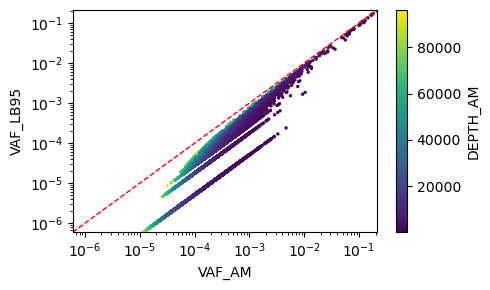

In [42]:
plot_scatter_with_diagonal(dg,'VAF_AM','VAF_LB95',color_col='DEPTH_AM')

/tmp/ipykernel_3826706/1240338464.py:8: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(1e-7,0)


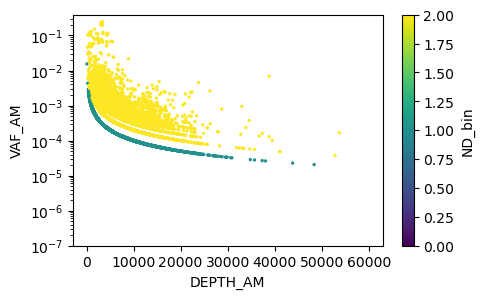

In [43]:
plt.figure(figsize=(5, 3))
sc = plt.scatter(dg['DEPTH_ND'], dg['VAF_ND'], c=dg['ND_bin'].astype(int), s=2)
plt.xlabel('DEPTH_AM')
plt.ylabel('VAF_AM')
plt.yscale('log')
#plt.xscale('log')
plt.colorbar(sc, label="ND_bin")
plt.ylim(1e-7,0)
plt.show()

/tmp/ipykernel_3826706/2363504043.py:8: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(1e-7,0)


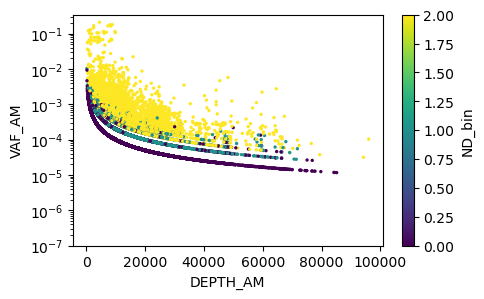

In [44]:
plt.figure(figsize=(5, 3))
sc = plt.scatter(dg['DEPTH_AM'], dg['VAF_AM'], c=dg['ND_bin'].astype(int), s=2)
plt.xlabel('DEPTH_AM')
plt.ylabel('VAF_AM')
plt.yscale('log')
#plt.xscale('log')
plt.colorbar(sc, label="ND_bin")
plt.ylim(1e-7,0)
plt.show()

/tmp/ipykernel_3826706/2848113451.py:7: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(1e-7,0)


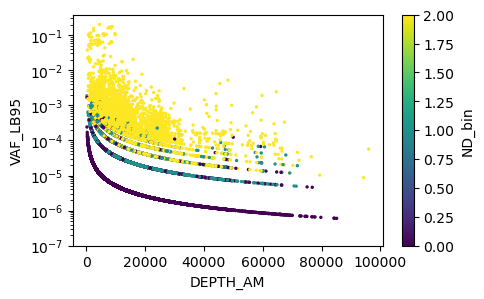

In [45]:
plt.figure(figsize=(5, 3))
sc = plt.scatter(dg['DEPTH_AM'], dg['VAF_LB95'], c=dg['ND_bin'].astype(int), s=2)
plt.xlabel('DEPTH_AM')
plt.ylabel('VAF_LB95')
plt.yscale('log')
#plt.xscale('log')
plt.ylim(1e-7,0)
plt.colorbar(sc, label="ND_bin")
plt.show()

In [46]:
dg_syn = dg[dg["Consequence"] == "synonymous_variant"]
dg_syn.head()

,MUTATION_ID,INDIVIDUAL_ID,SAMPLE_ID,DEPTH,DEPTH_AM,ALT_DEPTH,ALT_DEPTH_AM,DEPTH_ND,ALT_DEPTH_ND,SYMBOL,TYPE,Consequence,Protein_affecting,FILTER.not_in_exons,MUTATION,VAF,VAF_AM,VAF_ND,ND_bin,VAF_LB95
57,chr1:26729692:G>A,P19_0009,P19_0009_BTR_01,5733,9764,1,1,4031,0,ARID1A,SNV,synonymous_variant,non_protein_affecting,False,G>A,0.000174,0.000102,0.0,0,0.000005
62,chr1:26729704:G>C,P19_0008,P19_0008_BDO_01,6414,11681,1,1,5267,0,ARID1A,SNV,synonymous_variant,non_protein_affecting,False,G>C,0.000156,0.000086,0.0,0,0.000004
63,chr1:26729704:G>T,P19_0002,P19_0002_BTR_01,4454,7381,1,1,2927,0,ARID1A,SNV,synonymous_variant,non_protein_affecting,False,G>T,0.000225,0.000135,0.0,0,0.000007
64,chr1:26729704:G>A,P19_0002,P19_0002_BDO_01,4693,7005,1,1,2312,0,ARID1A,SNV,synonymous_variant,non_protein_affecting,False,G>A,0.000213,0.000143,0.0,0,0.000007
68,chr1:26729713:A>G,P19_0050,P19_0050_BDO_01,9413,18825,1,1,9412,0,ARID1A,SNV,synonymous_variant,non_protein_affecting,False,A>G,0.000106,0.000053,0.0,0,0.000003


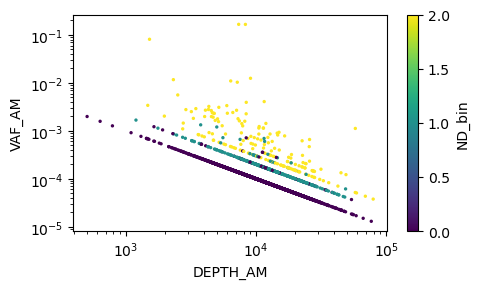

In [47]:
plot_scatter_with_diagonal(dg_syn,'DEPTH_AM','VAF_AM', plot_diag=False,color_col='ND_bin')

## Proportion of mutated sites in each depth bin

In [48]:
def mutation_proportion_by_depth_bin(
    df,
    df_depth,
    mut_depth_col="DEPTH",
    all_depth_col="DEPTH",
    bins=None,
):
    if bins is None:
        bins = [500, 1000,1500, 2000,2500,3000,3500,4000,4500,5000,5500,6000,  np.inf]
        #bins = [5000, 10000,15000, 20000,  np.inf]
        #bins = [10000,20000, 30000, 40000,  np.inf]

    df_mut = df[[mut_depth_col]].dropna().copy()
    df_all = df_depth[[all_depth_col]].dropna().copy()

    df_mut["depth_bin"] = pd.cut(
        df_mut[mut_depth_col],
        bins=bins,
        right=False
    )

    df_all["depth_bin"] = pd.cut(
        df_all[all_depth_col],
        bins=bins,
        right=False
    )

    n_mut = df_mut.groupby("depth_bin", observed=False).size()
    n_sites = df_all.groupby("depth_bin", observed=False).size()

    result = pd.DataFrame({
        "n_mutations": n_mut,
        "n_sites": n_sites
    }).fillna(0)

    result["proportion_mutated"] = (
        result["n_mutations"] / result["n_sites"]
    )

    result = result.reset_index()

    return result

In [49]:
df_depth_syn_all.head()

,CHROM,POS,CONTEXT,DEPTH,SAMPLE_ID
0,chr1,26729656,CCA,4467,P19_0024_BTR_01
1,chr1,26729659,GTC,4450,P19_0024_BTR_01
2,chr1,26729662,TTG,4490,P19_0024_BTR_01
3,chr1,26729668,ATC,4519,P19_0024_BTR_01
4,chr1,26729671,TCT,4576,P19_0024_BTR_01


In [50]:
depth_bin_summary = mutation_proportion_by_depth_bin(
    dg_syn,
    df_depth_syn_all,
    mut_depth_col="DEPTH",
    all_depth_col="DEPTH"
)
depth_bin_summary["depth_mid"] = [
    interval.mid for interval in depth_bin_summary["depth_bin"]
]

depth_bin_summary["p_hat"] = (
    -np.log(1 - depth_bin_summary["proportion_mutated"])
    / depth_bin_summary["depth_mid"]
)
depth_bin_summary = depth_bin_summary[np.isfinite(depth_bin_summary['depth_mid'])]
depth_bin_summary = depth_bin_summary[np.isfinite(depth_bin_summary['depth_mid'])]
depth_bin_summary

,depth_bin,n_mutations,n_sites,proportion_mutated,depth_mid,p_hat
0,"[500.0, 1000.0)",39,31241,0.001248,750.0,1.665519e-06
1,"[1000.0, 1500.0)",33,51525,0.000640,1250.0,5.125368e-07
2,"[1500.0, 2000.0)",48,64514,0.000744,1750.0,4.253151e-07
3,"[2000.0, 2500.0)",64,77883,0.000822,2250.0,3.653703e-07
4,"[2500.0, 3000.0)",86,94656,0.000909,2750.0,3.305331e-07
5,"[3000.0, 3500.0)",139,110957,0.001253,3250.0,3.856993e-07
6,"[3500.0, 4000.0)",172,126907,0.001355,3750.0,3.616647e-07
7,"[4000.0, 4500.0)",177,143515,0.001233,4250.0,2.903722e-07
8,"[4500.0, 5000.0)",228,142765,0.001597,4750.0,3.364856e-07
9,"[5000.0, 5500.0)",204,132697,0.001537,5250.0,2.930514e-07


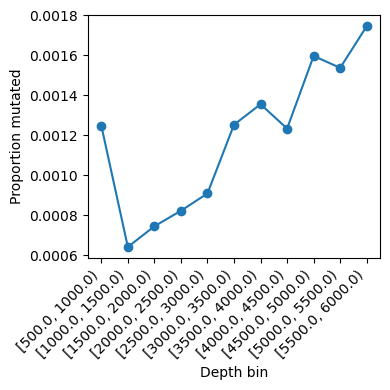

In [51]:
plt.figure(figsize=(4, 4))
plt.plot(
    depth_bin_summary["depth_bin"].astype(str),
    depth_bin_summary["proportion_mutated"],
    marker="o"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion mutated")
plt.xlabel("Depth bin")
plt.tight_layout()
plt.show()

In [52]:
depth_bin_summary['p_hat'].mean()

np.float64(4.791350950173659e-07)

## Pseudo-vafs

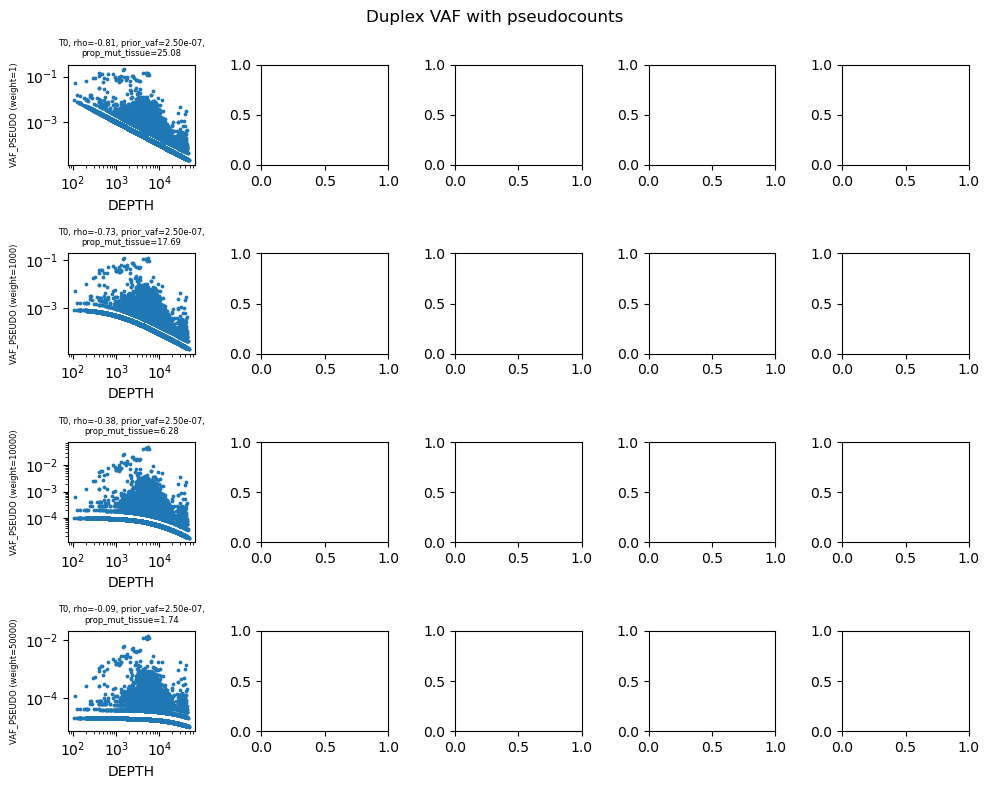

In [53]:
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
fig.suptitle('Duplex VAF with pseudocounts')
for i, weight in enumerate([1, 1000, 10000, 50000]):
    for j, time in enumerate(['T0']):
        #dg = get_mutations(time)
        #prior_vaf = dg['ALT_DEPTH'].sum() / dg['DEPTH'].sum()
        prior_vaf = 2.5e-07
        dg['VAF_PSEUDO'] = vaf_pseudocount(dg['ALT_DEPTH'], dg['DEPTH'], weight, prior_vaf=prior_vaf)
        axes[i, j].scatter(dg['DEPTH'], dg['VAF_PSEUDO'], alpha=1, s=3)
        rho = np.corrcoef(np.log(dg['DEPTH']), np.log(dg['VAF_PSEUDO']))[0, 1]
        axes[i, j].set_xlabel('DEPTH')
        axes[i, j].set_ylabel(f'VAF_PSEUDO (weight={weight})', fontsize=6)
        axes[i, j].set_yscale('log')
        axes[i, j].set_xscale('log')
        axes[i, j].set_title(f'{time}, rho={rho:.2f}, prior_vaf={prior_vaf:.2e},\nprop_mut_tissue={dg['VAF_PSEUDO'].sum():.2f}', fontsize=6)
plt.tight_layout()    
plt.show()

In [54]:
dg.head()

,MUTATION_ID,INDIVIDUAL_ID,SAMPLE_ID,DEPTH,DEPTH_AM,ALT_DEPTH,ALT_DEPTH_AM,DEPTH_ND,ALT_DEPTH_ND,SYMBOL,...,Consequence,Protein_affecting,FILTER.not_in_exons,MUTATION,VAF,VAF_AM,VAF_ND,ND_bin,VAF_LB95,VAF_PSEUDO
0,chr1:26729450:T>C,P19_0024,P19_0024_BTR_01,930,1817,1,1,887,0,ARID1A,...,5_prime_UTR_variant,non_protein_affecting,True,T>C,0.001075,0.000550,0.000000,0,0.000028,0.000020
1,chr1:26729474:TAG>T,P19_0014,P19_0014_BDO_01,1470,4192,1,2,2722,1,ARID1A,...,5_prime_UTR_variant,non_protein_affecting,True,TAG>T,0.000680,0.000477,0.000367,1,0.000085,0.000020
2,chr1:26729479:TTC>T,P19_0023,P19_0023_BDO_01,1961,3305,1,1,1344,0,ARID1A,...,5_prime_UTR_variant,non_protein_affecting,True,TTC>T,0.000510,0.000303,0.000000,0,0.000016,0.000019
3,chr1:26729563:G>C,P19_0023,P19_0023_BDO_01,3490,5847,1,1,2357,0,ARID1A,...,5_prime_UTR_variant,non_protein_affecting,True,G>C,0.000287,0.000171,0.000000,0,0.000009,0.000019
4,chr1:26729566:TA>T,P19_0040,P19_0040_BTR_01,2114,5011,1,3,2897,2,ARID1A,...,5_prime_UTR_variant,non_protein_affecting,True,TA>T,0.000473,0.000599,0.000690,2,0.000163,0.000019


In [55]:
weights = [0,500,1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000,15000, 20000, 25000, 30000]
prior_vafs = [1e-4, 1e-5, 1e-7, 1e-6]

time = "T0"

#dg = get_mutations(time).copy()
#dg = dg[dg["ALT_DEPTH_AM"] >= dg["ALT_DEPTH"]].copy()

dg["VAF_AM"] = dg["ALT_DEPTH_AM"] / dg["DEPTH_AM"]

for weight in weights:
    for prior_vaf in prior_vafs:
        col = f"VAF_PSEUDO_AM_w{weight}_p{prior_vaf:.0e}"
        dg[col] = vaf_pseudocount(dg["ALT_DEPTH_AM"],dg["DEPTH_AM"], weight, prior_vaf=prior_vaf)
        col = f"VAF_PSEUDO_w{weight}_p{prior_vaf:.0e}"
        dg[col] = vaf_pseudocount(dg["ALT_DEPTH"],dg["DEPTH"], weight, prior_vaf=prior_vaf)
    col = f"VAF_PSEUDO_ND_w{weight}"
    dg[col] = vaf_pseudocount_nd(dg["ALT_DEPTH_AM"],dg["DEPTH_AM"], weight, prior_vaf=dg["VAF_ND"])

/tmp/ipykernel_3826706/2467412557.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dg[col] = vaf_pseudocount(dg["ALT_DEPTH_AM"],dg["DEPTH_AM"], weight, prior_vaf=prior_vaf)
/tmp/ipykernel_3826706/2467412557.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dg[col] = vaf_pseudocount(dg["ALT_DEPTH"],dg["DEPTH"], weight, prior_vaf=prior_vaf)
/tmp/ipykernel_3826706/2467412557.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.

In [56]:
dg.head()

,MUTATION_ID,INDIVIDUAL_ID,SAMPLE_ID,DEPTH,DEPTH_AM,ALT_DEPTH,ALT_DEPTH_AM,DEPTH_ND,ALT_DEPTH_ND,SYMBOL,...,VAF_PSEUDO_ND_w25000,VAF_PSEUDO_AM_w30000_p1e-04,VAF_PSEUDO_w30000_p1e-04,VAF_PSEUDO_AM_w30000_p1e-05,VAF_PSEUDO_w30000_p1e-05,VAF_PSEUDO_AM_w30000_p1e-07,VAF_PSEUDO_w30000_p1e-07,VAF_PSEUDO_AM_w30000_p1e-06,VAF_PSEUDO_w30000_p1e-06,VAF_PSEUDO_ND_w30000
0,chr1:26729450:T>C,P19_0024,P19_0024_BTR_01,930,1817,1,1,887,0,ARID1A,...,0.000037,0.000126,0.000129,0.000041,0.000042,0.000032,0.000032,0.000032,0.000033,0.000031
1,chr1:26729474:TAG>T,P19_0014,P19_0014_BDO_01,1470,4192,1,2,2722,1,ARID1A,...,0.000383,0.000146,0.000127,0.000067,0.000041,0.000059,0.000032,0.000059,0.000033,0.000381
2,chr1:26729479:TTC>T,P19_0023,P19_0023_BDO_01,1961,3305,1,1,1344,0,ARID1A,...,0.000035,0.000120,0.000125,0.000039,0.000041,0.000030,0.000031,0.000031,0.000032,0.000030
3,chr1:26729563:G>C,P19_0023,P19_0023_BDO_01,3490,5847,1,1,2357,0,ARID1A,...,0.000032,0.000112,0.000119,0.000036,0.000039,0.000028,0.000030,0.000029,0.000031,0.000028
4,chr1:26729566:TA>T,P19_0040,P19_0040_BTR_01,2114,5011,1,3,2897,2,ARID1A,...,0.000675,0.000171,0.000125,0.000094,0.000040,0.000086,0.000031,0.000087,0.000032,0.000677


In [57]:
dg[["MUTATION_ID","ALT_DEPTH", "DEPTH", "ALT_DEPTH_ND", "DEPTH_ND", "VAF","VAF_AM","VAF_PSEUDO_AM_w10000_p1e-07","VAF_PSEUDO_ND_w10000"]].head()

,MUTATION_ID,ALT_DEPTH,DEPTH,ALT_DEPTH_ND,DEPTH_ND,VAF,VAF_AM,VAF_PSEUDO_AM_w10000_p1e-07,VAF_PSEUDO_ND_w10000
0,chr1:26729450:T>C,1,930,0,887,0.001075,0.000550,0.000085,0.000085
1,chr1:26729474:TAG>T,1,1470,1,2722,0.000680,0.000477,0.000141,0.000400
2,chr1:26729479:TTC>T,1,1961,0,1344,0.000510,0.000303,0.000075,0.000075
3,chr1:26729563:G>C,1,3490,0,2357,0.000287,0.000171,0.000063,0.000063
4,chr1:26729566:TA>T,1,2114,2,2897,0.000473,0.000599,0.000200,0.000660


In [58]:
dg['VAF_correction_LB95'] = dg['VAF_AM']-dg['VAF_LB95']
dg['VAF_correction_pseudocount'] = dg['VAF_AM']-dg['VAF_PSEUDO_AM_w10000_p1e-07']
dg['VAF_correction_pseudocount_nd'] = dg['VAF_AM']-dg['VAF_PSEUDO_ND_w10000']
dg['log_VAF_AM'] = np.log(dg['VAF_AM'])
dg['log_DEPTH_AM'] = np.log(dg['DEPTH_AM'])

/tmp/ipykernel_3826706/3797373819.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dg['VAF_correction_LB95'] = dg['VAF_AM']-dg['VAF_LB95']
/tmp/ipykernel_3826706/3797373819.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dg['VAF_correction_pseudocount'] = dg['VAF_AM']-dg['VAF_PSEUDO_AM_w10000_p1e-07']
/tmp/ipykernel_3826706/3797373819.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once 

In [59]:
#dg["VAF_mle"] = dg.apply(estimate_vaf, axis=1)
dg["VAF"] = dg["ALT_DEPTH"]/dg["DEPTH"]
dg["VAF_AM"] = dg["ALT_DEPTH_AM"]/dg["DEPTH_AM"]
dg.head()

,MUTATION_ID,INDIVIDUAL_ID,SAMPLE_ID,DEPTH,DEPTH_AM,ALT_DEPTH,ALT_DEPTH_AM,DEPTH_ND,ALT_DEPTH_ND,SYMBOL,...,VAF_PSEUDO_AM_w30000_p1e-07,VAF_PSEUDO_w30000_p1e-07,VAF_PSEUDO_AM_w30000_p1e-06,VAF_PSEUDO_w30000_p1e-06,VAF_PSEUDO_ND_w30000,VAF_correction_LB95,VAF_correction_pseudocount,VAF_correction_pseudocount_nd,log_VAF_AM,log_DEPTH_AM
0,chr1:26729450:T>C,P19_0024,P19_0024_BTR_01,930,1817,1,1,887,0,ARID1A,...,0.000032,0.000032,0.000032,0.000033,0.000031,0.000522,0.000466,0.000466,-7.504942,7.504942
1,chr1:26729474:TAG>T,P19_0014,P19_0014_BDO_01,1470,4192,1,2,2722,1,ARID1A,...,0.000059,0.000032,0.000059,0.000033,0.000381,0.000392,0.000336,0.000077,-7.647786,8.340933
2,chr1:26729479:TTC>T,P19_0023,P19_0023_BDO_01,1961,3305,1,1,1344,0,ARID1A,...,0.000030,0.000031,0.000031,0.000032,0.000030,0.000287,0.000227,0.000227,-8.103192,8.103192
3,chr1:26729563:G>C,P19_0023,P19_0023_BDO_01,3490,5847,1,1,2357,0,ARID1A,...,0.000028,0.000030,0.000029,0.000031,0.000028,0.000162,0.000108,0.000108,-8.673684,8.673684
4,chr1:26729566:TA>T,P19_0040,P19_0040_BTR_01,2114,5011,1,3,2897,2,ARID1A,...,0.000086,0.000031,0.000087,0.000032,0.000677,0.000435,0.000399,-0.000061,-7.420778,8.519391


In [60]:
dg.columns

Index(['MUTATION_ID', 'INDIVIDUAL_ID', 'SAMPLE_ID', 'DEPTH', 'DEPTH_AM',
       'ALT_DEPTH', 'ALT_DEPTH_AM', 'DEPTH_ND', 'ALT_DEPTH_ND', 'SYMBOL',
       ...
       'VAF_PSEUDO_AM_w30000_p1e-07', 'VAF_PSEUDO_w30000_p1e-07',
       'VAF_PSEUDO_AM_w30000_p1e-06', 'VAF_PSEUDO_w30000_p1e-06',
       'VAF_PSEUDO_ND_w30000', 'VAF_correction_LB95',
       'VAF_correction_pseudocount', 'VAF_correction_pseudocount_nd',
       'log_VAF_AM', 'log_DEPTH_AM'],
      dtype='object', length=170)

In [61]:
#plot_scatter_with_diagonal(dg,'VAF_AM','VAF_mle',color_col='DEPTH_AM')

In [62]:
dg_SNV = dg[dg['TYPE']=='SNV']

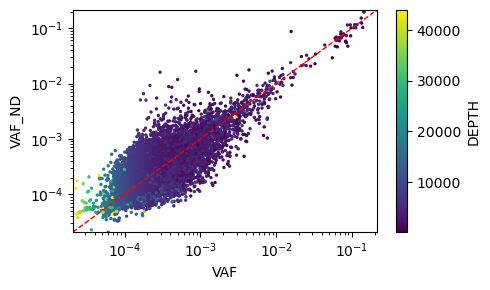

In [63]:
plot_scatter_with_diagonal(dg_SNV,'VAF','VAF_ND',color_col='DEPTH')

In [64]:
dg[dg['DEPTH']> 80000][['ALT_DEPTH','DEPTH','ALT_DEPTH_AM','DEPTH_AM','VAF','VAF_AM']].tail()

,ALT_DEPTH,DEPTH,ALT_DEPTH_AM,DEPTH_AM,VAF,VAF_AM


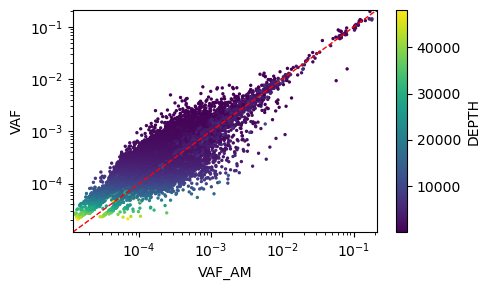

In [65]:
plot_scatter_with_diagonal(dg,'VAF_AM','VAF',color_col='DEPTH')

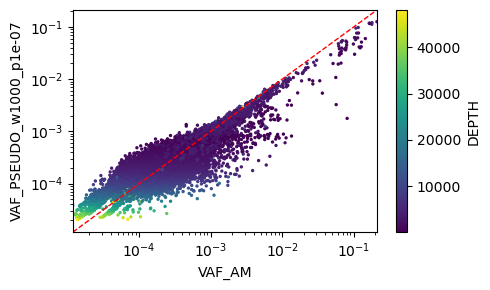

In [82]:
plot_scatter_with_diagonal(dg,'VAF_AM','VAF_PSEUDO_w1000_p1e-07',color_col='DEPTH')

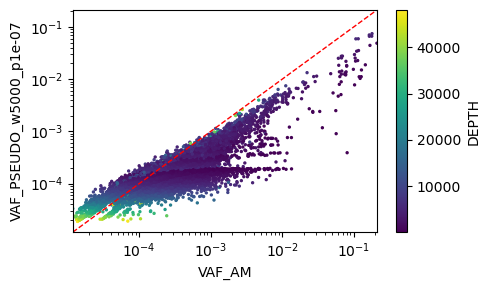

In [66]:
plot_scatter_with_diagonal(dg,'VAF_AM','VAF_PSEUDO_w5000_p1e-07',color_col='DEPTH')

In [67]:
#plot_scatter_with_diagonal(dg,'VAF_AM','VAF_mle',color_col='DEPTH')

In [68]:
#dg['mle_shrinkage'] = dg['VAF'] - dg['VAF_mle']
dg['VAFminusVAF_AM'] = dg['VAF'] - dg['VAF_AM'] 

/tmp/ipykernel_3826706/83105840.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dg['VAFminusVAF_AM'] = dg['VAF'] - dg['VAF_AM']


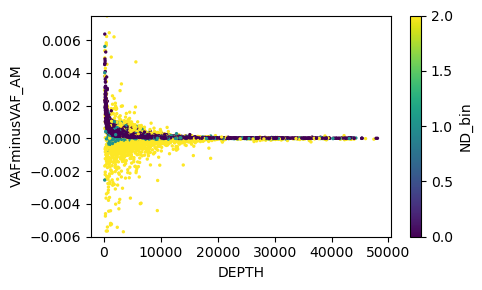

In [69]:
plot_scatter_with_diagonal(dg,'DEPTH', 'VAFminusVAF_AM', plot_diag = False, color_col='ND_bin', log_scale_y=False, log_scale_x=False, ylim=[-0.006, 0.0075])

In [70]:
dg['VAFpseudominusVAF_AM'] = dg['VAF_PSEUDO_w500_p1e-05'] - dg['VAF_AM'] 

/tmp/ipykernel_3826706/838473623.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dg['VAFpseudominusVAF_AM'] = dg['VAF_PSEUDO_w500_p1e-05'] - dg['VAF_AM']


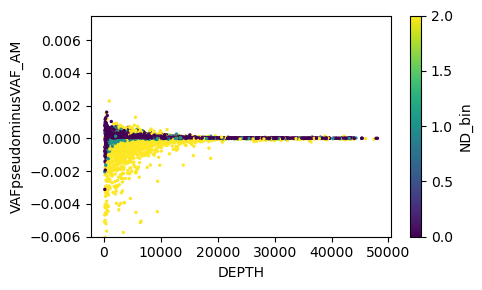

In [71]:
plot_scatter_with_diagonal(dg,'DEPTH', 'VAFpseudominusVAF_AM', plot_diag = False, color_col='ND_bin', log_scale_y=False, log_scale_x=False, ylim=[-0.006, 0.0075])

In [72]:
#plot_scatter_with_diagonal(dg,'DEPTH', 'mle_shrinkage', plot_diag = False, color_col='ND_bin', log_scale_y=False, log_scale_x=False)

In [73]:
#plot_scatter_with_diagonal(dg,'DEPTH', 'VAF_mle', plot_diag = False, color_col='ND_bin', log_scale_y=True, log_scale_x=False)

In [74]:
complement = {
    "A": "T",
    "T": "A",
    "C": "G",
    "G": "C"
}

def canonical_mut(mut):
    ref, alt = mut.split(">")
    if ref in ["C", "T"]:
        return mut
    return f"{complement[ref]}>{complement[alt]}"

dg_SNV["MUT_CLASS"] = dg_SNV["MUTATION"].apply(canonical_mut)

/tmp/ipykernel_3826706/2366591958.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dg_SNV["MUT_CLASS"] = dg_SNV["MUTATION"].apply(canonical_mut)
/tmp/ipykernel_3826706/2366591958.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dg_SNV["MUT_CLASS"] = dg_SNV["MUTATION"].apply(canonical_mut)


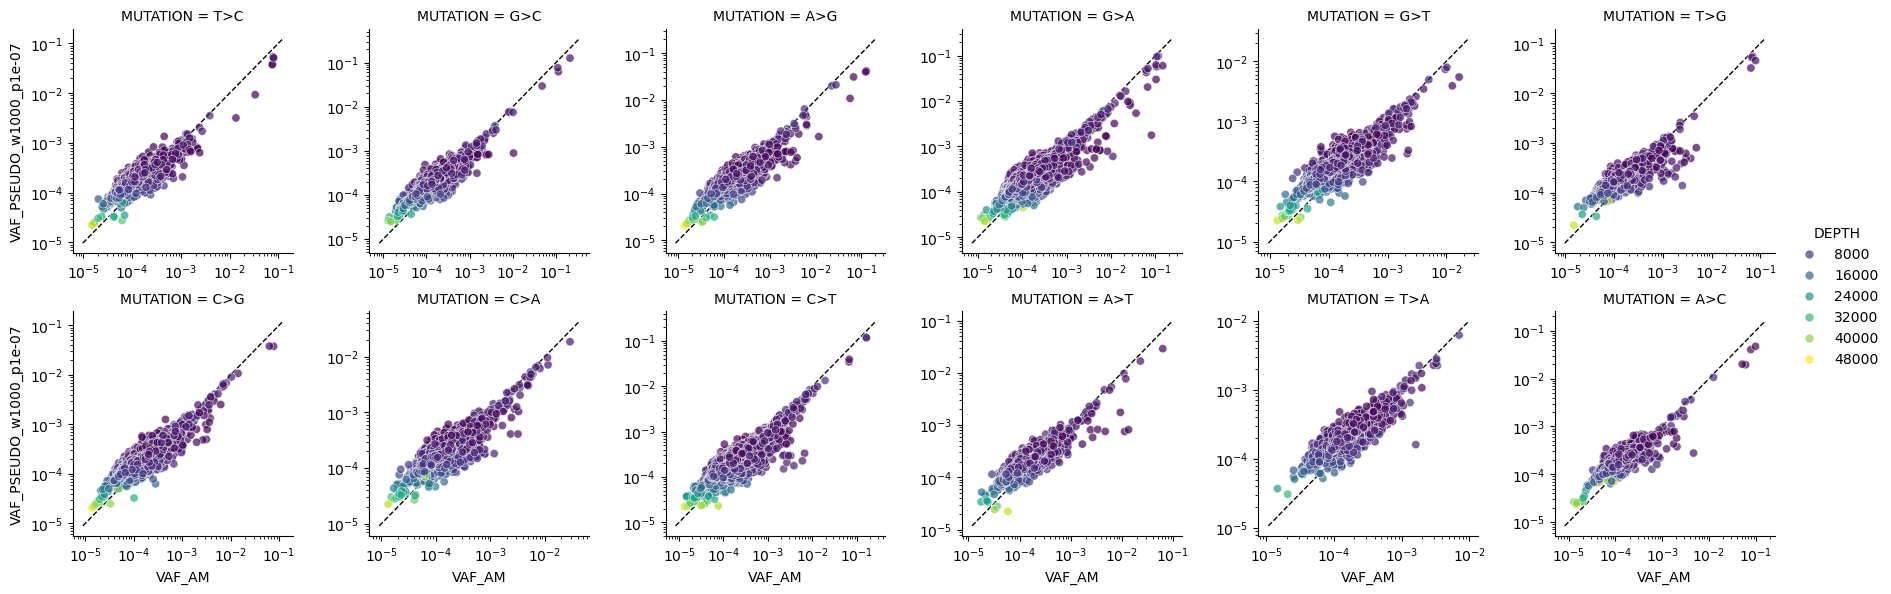

In [75]:
plot_facet_scatter(dg_SNV, x="VAF_AM",y="VAF_PSEUDO_w1000_p1e-07")

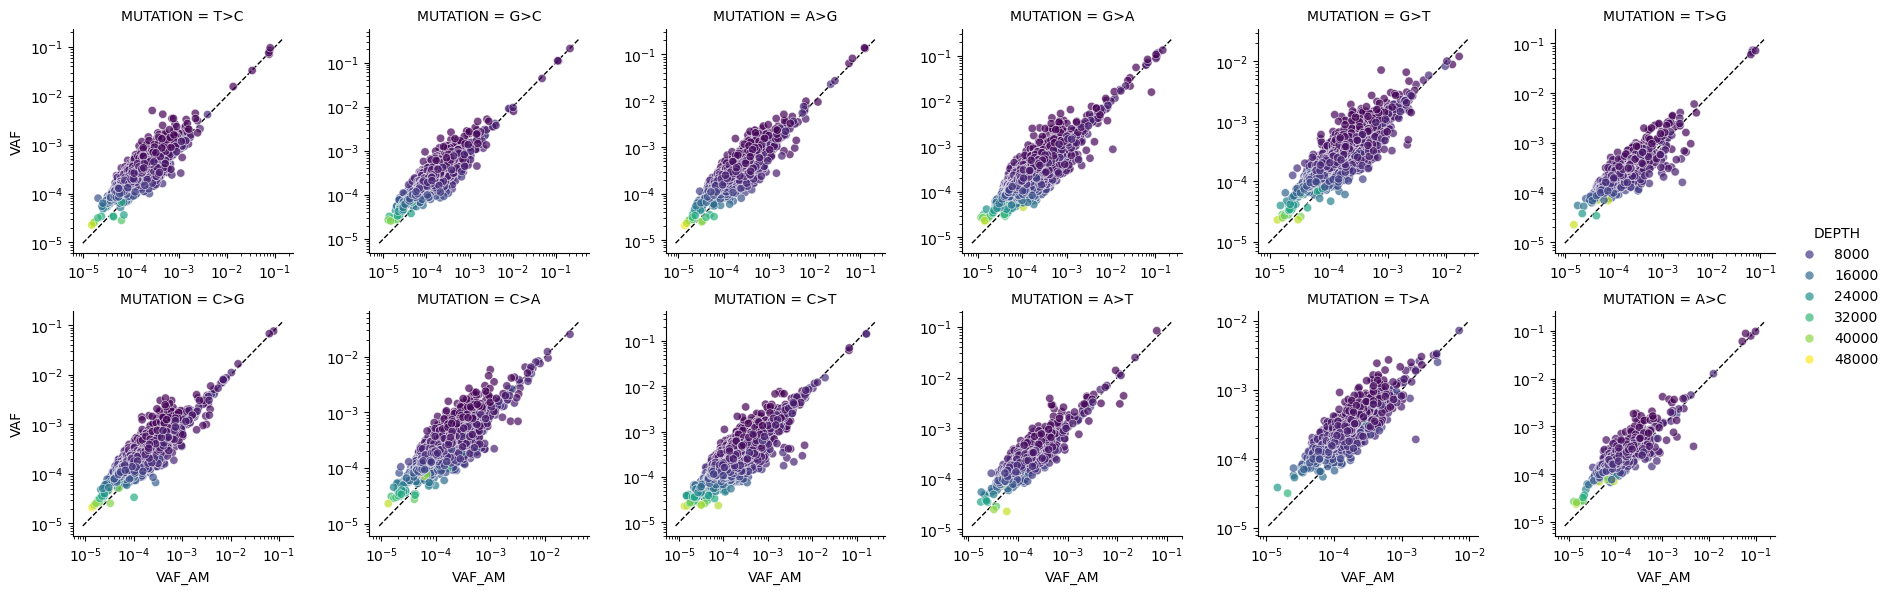

In [76]:
plot_facet_scatter(dg_SNV, x="VAF_AM",y="VAF")

## Test different weights values with fixed prior

In [78]:
def calc_vaf_distance_summary(
    df,
    weights,
    vaf_col="VAF",
    target_col="VAF_AM",
    pseudo_prefix="VAF_PSEUDO",
    prior="p1e-07",
    depth_col="DEPTH",
    depth_quantile=0.1,
    large_clone_threshold=1e-2,
):
    """
    Calculate distance between VAF_PSEUDO and target VAF column
    for low-depth clones and large clones.
    """

    depth_cutoff = df[depth_col].quantile(depth_quantile)

    df_low_depth = df[(df[depth_col] < depth_cutoff) & (df['ALT_DEPTH'] < 2)].copy()
    df_large = df[df[target_col] > large_clone_threshold].copy()

    # Reference: original VAF vs target VAF
    ref_dist_log_low_depth = np.abs(np.log10(df_low_depth[vaf_col]) - np.log10(df_low_depth[target_col])).sum()
    ref_dist_log_large = np.abs(np.log10(df_large[vaf_col]) - np.log10(df_large[target_col])).sum()
    ref_dist_low_depth = np.abs(df_low_depth[vaf_col] - df_low_depth[target_col]).sum()
    ref_dist_large = np.abs(df_large[vaf_col] - df_large[target_col]).sum()

    results = []

    for w in weights:

        col = f"{pseudo_prefix}_w{w}_{prior}"

        dist_log_low_depth = np.abs(np.log10(df_low_depth[col]) -  np.log10(df_low_depth[target_col]))
        dist_log_large = np.abs(np.log10(df_large[col]) -  np.log10(df_large[target_col]))
        dist_low_depth = np.abs(df_low_depth[col] -  df_low_depth[target_col])
        dist_large = np.abs(df_large[col] -  df_large[target_col])

        results.append({
            "w": w,
            "sum_dist_log_low_depth": dist_log_low_depth.sum(),
            "sum_dist_low_depth": dist_low_depth.sum(),
            "mean_dist_log_low_depth": dist_log_low_depth.mean(),
            "sum_dist_log_large_clones": dist_log_large.sum(),
            "sum_dist_large_clones": dist_large.sum(),
            "mean_dist_log_large_clones": dist_log_large.mean(),
            "n_low_depth": len(df_low_depth),
            "n_large_clones": len(df_large),
            "depth_cutoff": depth_cutoff,
            "ref_dist_log_low_depth": ref_dist_log_low_depth,
            "ref_dist_log_large_clones": ref_dist_log_large,
            "ref_dist_low_depth": ref_dist_low_depth,
            "ref_dist_large_clones": ref_dist_large,
        })

    return pd.DataFrame(results)

In [79]:
def plot_vaf_distance_summary(
    dist_df,
    use_mean=False,
    figsize=(7, 4),
    log_dist=False,
    log_y=False,
):
    """
    Plot pseudocount distance curves and reference VAF vs VAF_AM distances.
    """

    if use_mean:
        y_low = "mean_dist_log_low_depth"
        y_large = "mean_dist_large_clones_log"
        ylabel = "Mean log-distance"
    else:
        if log_dist:
            ref_low = dist_df["ref_dist_log_low_depth"].iloc[0]
            ref_large = dist_df["ref_dist_log_large_clones"].iloc[0]
            y_low = "sum_dist_log_low_depth"
            y_large = "sum_dist_log_large_clones"
            ylabel = "Sum log distance"
        else:
            ref_low = dist_df["ref_dist_low_depth"].iloc[0]
            ref_large = dist_df["ref_dist_large_clones"].iloc[0]
            y_low = "sum_dist_low_depth"
            y_large = "sum_dist_large_clones"
            ylabel = "Sum distance"
            


    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        dist_df["w"],
        dist_df[y_low],
        "-o",
        lw=2,
        ms=5,
        label="Low-depth clones"
    )

    ax.plot(
        dist_df["w"],
        dist_df[y_large],
        "-o",
        lw=2,
        ms=5,
        label="Large clones"
    )

    ax.axhline(
        ref_low,
        color="C0",
        linestyle="--",
        linewidth=2,
        label="VAF vs VAF_AM (low-depth)"
    )

    ax.axhline(
        ref_large,
        color="C1",
        linestyle="--",
        linewidth=2,
        label="VAF vs VAF_AM (large)"
    )

    ax.set_xlabel("Pseudocount weight (w)")
    ax.set_ylabel(ylabel)

    if log_y:
        ax.set_yscale("log")

    ax.legend(frameon=False)
    sns.despine()
    plt.tight_layout()

    return fig, ax

In [80]:
weights = [0, 500,1000, 2000, 3000, 4000, 5000, 
           6000, 7000, 8000, 9000, 10000]

dist_df = calc_vaf_distance_summary(
    dg,
    weights=weights,
    vaf_col="VAF",
    target_col="VAF_AM",
    pseudo_prefix="VAF_PSEUDO",
    prior="p1e-07",
    depth_col="DEPTH",
    depth_quantile=0.2,
    large_clone_threshold=1e-2,
)

In [81]:
dist_df

,w,sum_dist_log_low_depth,sum_dist_low_depth,mean_dist_log_low_depth,sum_dist_log_large_clones,sum_dist_large_clones,mean_dist_log_large_clones,n_low_depth,n_large_clones,depth_cutoff,ref_dist_log_low_depth,ref_dist_log_large_clones,ref_dist_low_depth,ref_dist_large_clones
0,0,3527.888178,3.415243,0.309844,7.817408,0.664000,0.081431,11386,96,3414.0,3527.888178,7.817408,3.415243,0.664
1,500,2610.687742,2.091701,0.229289,20.294490,1.697115,0.211401,11386,96,3414.0,3527.888178,7.817408,3.415243,0.664
2,1000,2033.469503,1.607692,0.178594,30.237224,2.389121,0.314971,11386,96,3414.0,3527.888178,7.817408,3.415243,0.664
3,2000,1688.842674,1.435039,0.148326,43.999847,3.138425,0.458332,11386,96,3414.0,3527.888178,7.817408,3.415243,0.664
4,3000,1994.797591,1.617554,0.175197,53.920358,3.562516,0.561670,11386,96,3414.0,3527.888178,7.817408,3.415243,0.664
5,4000,2521.200466,1.845868,0.221430,61.776245,3.843166,0.643503,11386,96,3414.0,3527.888178,7.817408,3.415243,0.664
6,5000,3086.575203,2.047770,0.271085,68.312129,4.045031,0.711585,11386,96,3414.0,3527.888178,7.817408,3.415243,0.664
7,6000,3632.572849,2.214958,0.319039,73.921927,4.198151,0.770020,11386,96,3414.0,3527.888178,7.817408,3.415243,0.664
8,7000,4145.200470,2.352740,0.364061,78.842464,4.318715,0.821276,11386,96,3414.0,3527.888178,7.817408,3.415243,0.664
9,8000,4622.228957,2.467144,0.405957,83.228360,4.416326,0.866962,11386,96,3414.0,3527.888178,7.817408,3.415243,0.664


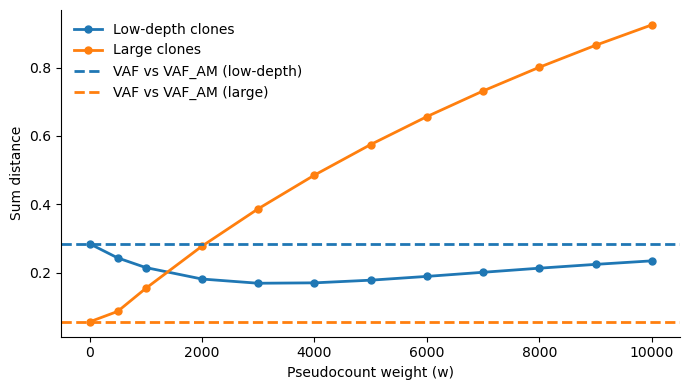

In [165]:
fig, ax = plot_vaf_distance_summary(
    dist_df,
    log_dist=False,   
    use_mean=False,
    log_y=False
)

In [88]:
#plt.figure(figsize=(5, 3))
#sc = plt.scatter(dg['DEPTH_AM'], dg['VAF_mle'], c=dg['ND_bin'].astype(int), s=2)
#plt.xlabel('DEPTH_AM')
#plt.ylabel('VAF_mle')
#plt.yscale('log')
#plt.xscale('log')
#plt.colorbar(sc, label="ND_bin")
#plt.ylim(1e-7,0)
#plt.show()

In [ ]:
#plot_scatter_with_diagonal(dg,'DEPTH_AM', 'VAF_correction_LB95', plot_diag = False, color_col='log_VAF_AM', log_scale_y=True)

In [ ]:
#plot_scatter_with_diagonal(dg,'VAF_correction_LB95', 'VAF_correction_pseudocount', plot_diag = True, color_col='log_DEPTH_AM', log_scale_y=True, log_scale_x=True)

In [ ]:
#plot_scatter_with_diagonal(dg,'VAF_LB95', 'VAF_PSEUDO_AM_w5000_p1e-07', plot_diag = True, color_col='ND_bin', log_scale_y=True, log_scale_x=True)#

In [ ]:
#plot_scatter_with_diagonal(dg,'VAF', 'VAF_PSEUDO_ND_w10000', plot_diag = True, color_col='ND_bin', log_scale_y=True, log_scale_x=True)

In [ ]:
#plot_scatter_with_diagonal(dg,'VAF', 'VAF_PSEUDO_AM_w10000_p1e-07', plot_diag = True, color_col='ND_bin', log_scale_y=True, log_scale_x=True)

In [ ]:
#dg.head()

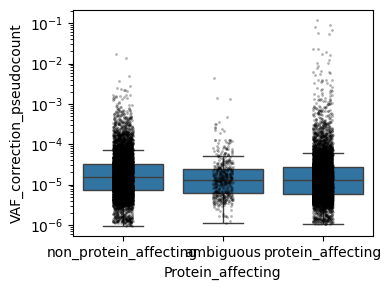

In [100]:
plt.figure(figsize=(4, 3))

sns.boxplot(
    data=dg,
    x="Protein_affecting",
    y="VAF_correction_pseudocount",
    fliersize=0
)

sns.stripplot(
    data=dg,
    x="Protein_affecting",
    y="VAF_correction_pseudocount",
    size=2,
    alpha=0.3,
    jitter=True,
    color="black"
)

plt.yscale("log")
plt.tight_layout()
plt.show()

In [ ]:
plot_scatter_with_diagonal(dg,'DEPTH', 'VAF_PSEUDO_AM_w10000_p1e-07', plot_diag = False, color_col='ND_bin', log_scale_y=True, log_scale_x=False)

In [ ]:
plot_scatter_with_diagonal(dg,'DEPTH', 'VAF_PSEUDO_ND_w10000', plot_diag = False, color_col='ND_bin', log_scale_y=True, log_scale_x=False)

In [ ]:
plot_scatter_with_diagonal(dg,'VAF_PSEUDO_AM_w1000_p1e-07', 'VAF_PSEUDO_AM_w10000_p1e-07', plot_diag = True, color_col='log_DEPTH_AM', log_scale_y=True, log_scale_x=True)

In [ ]:
plot_scatter_with_diagonal(dg,'VAF_PSEUDO_AM_w5000_p1e-07', 'VAF_PSEUDO_ND_w1000', plot_diag = True, color_col='log_DEPTH_AM', log_scale_y=True, log_scale_x=True)

In [ ]:
print(dg["VAF"].sum())
print(dg["VAF_AM"].sum())
print(dg["VAF_ND"].sum())
print(dg["VAF_LB95"].sum())
print(dg["VAF_PSEUDO_AM_w10000_p1e-07"].sum())
print(dg["VAF_PSEUDO_AM_w5000_p1e-07"].sum())
print(dg["VAF_PSEUDO_AM_w10000_p1e-04"].sum())

In [ ]:
dg.columns

In [ ]:
weights = [1000, 5000, 10000, 20000, 50000]
prior_vafs = [1e-7, 1e-6, 1e-5]

time = "T0"

#dg = get_mutations(time).copy()
#dg = dg[dg["ALT_DEPTH_AM"] >= dg["ALT_DEPTH"]].copy()

fig, axes = plt.subplots(
    len(prior_vafs),
    len(weights),
    figsize=(3 * len(weights),3 * len(prior_vafs)),
    sharex=True,
    sharey=True
)

for i, weight in enumerate(weights):
    for j, prior_vaf in enumerate(prior_vafs):

        vaf_pseudo = vaf_pseudocount(
            dg["ALT_DEPTH_AM"],
            dg["DEPTH_AM"],
            weight,
            prior_vaf=prior_vaf
        )

        ax = axes[j, i]

        sc = ax.scatter(
            dg["VAF_AM"],
            vaf_pseudo,
            s=2,
            alpha=1,
            c=dg['log_DEPTH_AM']
        )

        lims = [
            min(dg["VAF_AM"].min(), vaf_pseudo.min()),
            max(dg["VAF_AM"].max(), vaf_pseudo.max())
        ]

        ax.plot(lims, lims, "r--", lw=1)

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(lims)
        ax.set_ylim(lims)

        rho = np.corrcoef(
            np.log(dg["VAF_AM"]),
            np.log(vaf_pseudo)
        )[0, 1]

        ax.set_title(
            f"w={weight}, prior={prior_vaf:.0e}\nr={rho:.2f}",
            fontsize=8
        )

        if j == len(prior_vafs) - 1:
            ax.set_xlabel("VAF_AM")
        if i == 0:
            ax.set_ylabel("VAF_PSEUDO_AM")

fig.suptitle(f"{time}: VAF_AM vs pseudocount VAF", y=1.02)
cbar = fig.colorbar(
    sc,
    ax=axes,
    location="right",
    pad=0.1,
    shrink=0.8
)

cbar.set_label("log10(DEPTH_AM)")
#plt.tight_layout()
plt.show()

In [ ]:
dg.head()

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
fig.suptitle('All molecules VAF with pseudocounts')
for i, weight in enumerate([1, 1000, 20000, 50000]):
    for j, time in enumerate(['T0']):
        dg = get_mutations(time)
        dg = dg[dg["ALT_DEPTH_AM"] >= dg["ALT_DEPTH"]]
        #prior_vaf = dg['ALT_DEPTH_AM'].sum() / dg['DEPTH_AM'].sum()
        prior_vaf = 1.029339e-07

        dg['VAF_PSEUDO_AM'] = vaf_pseudocount(dg['ALT_DEPTH_AM'], dg['DEPTH_AM'], weight, prior_vaf=prior_vaf)
        axes[i, j].scatter(dg['DEPTH_AM'], dg['VAF_PSEUDO_AM'], alpha=1, s=2)
        rho = np.corrcoef(np.log(dg['DEPTH_AM']), np.log(dg['VAF_PSEUDO_AM']))[0, 1]
        axes[i, j].set_xlabel('DEPTH')
        axes[i, j].set_ylabel(f'VAF_PSEUDO (weight={weight})', fontsize=6)
        axes[i, j].set_yscale('log')
        axes[i, j].set_xscale('log')
        axes[i, j].set_title(f'{time}, rho={rho:.2f}, prior_vaf={prior_vaf:.2e},\nprop_mut_tissue={dg['VAF_PSEUDO_AM'].sum():.2f}', fontsize=6)
plt.tight_layout()    
plt.show()

### PMB sample-wise

In [ ]:
df_sum = (
    dg.groupby('SAMPLE_ID')[['VAF', 'VAF_AM', 'VAF_PSEUDO_AM_w5000_p1e-07']]
      .sum()
      .reset_index()
)
df_sum.head()

In [ ]:
df_sum_with_depth = df_sum.merge(df_mean_depth, on= 'SAMPLE_ID')
df_sum_with_depth['VAFmisunVAFcorrected'] = df_sum_with_depth['VAF'] - df_sum_with_depth['VAF_PSEUDO_AM_w5000_p1e-07']
df_sum_with_depth.head()

In [ ]:
plot_scatter_with_diagonal(df_sum_with_depth,'VAF', 'VAF_AM', plot_diag = True, log_scale_y=False, log_scale_x=False,color_col='DEPTH', s=30)

In [ ]:
plot_scatter_with_diagonal(df_sum_with_depth,'DEPTH', 'VAFmisunVAFcorrected', plot_diag = False, log_scale_y=False, log_scale_x=False, s=30)

In [ ]:
plot_scatter_with_diagonal(df_sum_with_depth,'VAF', 'VAF_PSEUDO_AM_w5000_p1e-07', plot_diag = True, log_scale_y=False, log_scale_x=False,color_col='DEPTH', s=30)

In [ ]:
plot_scatter_with_diagonal(df_sum_with_depth,'VAF_AM', 'VAF_PSEUDO_AM_w5000_p1e-07', plot_diag = True, log_scale_y=False, log_scale_x=False,color_col='DEPTH', s=30)

In [ ]:
df_sum_by_gene = (
    dg.groupby(['SAMPLE_ID','SYMBOL'])[['VAF', 'VAF_AM', 'VAF_PSEUDO_AM_w5000_p1e-07']]
      .sum()
      .reset_index()
)
df_sum_by_gene_with_depth = df_sum_by_gene.merge(df_mean_depth, on= 'SAMPLE_ID')

df_sum_by_gene_with_depth.head()


In [ ]:
g = sns.relplot(
    data=df_sum_by_gene_with_depth[df_sum_by_gene_with_depth['SYMBOL'].isin(genes)],
    x="VAF_AM",
    y="VAF_PSEUDO_AM_w5000_p1e-07",
    col="SYMBOL",
    hue="DEPTH",
    palette="viridis",
    kind="scatter",
    height=2.5,
    aspect=1,
    alpha=1,
    legend=False,
    facet_kws={'sharex': False, 'sharey': False}
)

# add diagonal
for ax in g.axes.flat:
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    lo = max(min(xmin, ymin), 1e-8)
    hi = max(xmax, ymax)

    ax.plot([lo, hi], [lo, hi], '--', color='black', lw=1)

# add shared colorbar
norm = plt.Normalize(
    df_sum_by_gene_with_depth["DEPTH"].min(),
    df_sum_by_gene_with_depth["DEPTH"].max()
)

sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])

cbar = g.figure.colorbar(
    sm,
    ax=g.axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.15
)

cbar.set_label("DEPTH")

#g.set_axis_labels("VAF", "Corrected VAF")
plt.show()

In [ ]:
df_sum_by_gene_with_depth['DEPTH'].dtype

## sample-wise

In [ ]:
fig, axes = plt.subplots(ncols=4, figsize=(12, 3))
time = 'T0'
id, sub_dg = next(get_mutations_from_samples(time))

for i, weight in enumerate([1, 1000, 10000, 20000]):

    #prior_vaf = sub_dg['ALT_DEPTH_AM'].sum() / sub_dg['DEPTH_AM'].sum()
    prior_vaf = 1.029339e-07

    sub_dg['VAF_PSEUDO'] = vaf_pseudocount(sub_dg['ALT_DEPTH_AM'], sub_dg['DEPTH_AM'], weight, prior_vaf=prior_vaf)
    axes[i].scatter(sub_dg['DEPTH_AM'], sub_dg['VAF_PSEUDO'], alpha=1, s=2)
    rho = np.corrcoef(np.log(sub_dg['DEPTH_AM']), np.log(sub_dg['VAF_PSEUDO']))[0, 1]
    axes[i].set_xlabel('DEPTH')
    axes[i].set_ylabel(f'VAF_PSEUDO (weight={weight})', fontsize=6)
    axes[i].set_yscale('log')
    axes[i].set_xscale('log')
    axes[i].set_title(f'{time}, rho={rho:.2f}, prior_vaf={prior_vaf:.2e},\nprop_mut_tissue={sub_dg['VAF_PSEUDO'].sum():.2f}', fontsize=6)
    for ax in axes:
        ax.set_xticks([1e4, 1e5])

fig.suptitle(f'All molecules VAF with pseudocounts: {id}')

plt.tight_layout()    
plt.show()

In [ ]:
time = 'T0'

for id, sub_dg in get_mutations_from_samples(time):
    fig, axes = plt.subplots(ncols=4, figsize=(12, 3))
    for i, weight in enumerate([1, 1000, 10000, 20000]):

        #prior_vaf = sub_dg['ALT_DEPTH_AM'].sum() / sub_dg['DEPTH_AM'].sum()
        prior_vaf = 1.029339e-07
        sub_dg = sub_dg[sub_dg["ALT_DEPTH_AM"] >= sub_dg["ALT_DEPTH"]]

        sub_dg['VAF_PSEUDO'] = vaf_pseudocount(sub_dg['ALT_DEPTH_AM'], sub_dg['DEPTH_AM'], weight, prior_vaf=prior_vaf)
        axes[i].scatter(sub_dg['DEPTH_AM'], sub_dg['VAF_PSEUDO'], alpha=1, s=2)
        rho = np.corrcoef(np.log(sub_dg['DEPTH_AM']), np.log(sub_dg['VAF_PSEUDO']))[0, 1]
        axes[i].set_xlabel('DEPTH')
        axes[i].set_ylabel(f'VAF_PSEUDO (weight={weight})', fontsize=6)
        axes[i].set_yscale('log')
        axes[i].set_xscale('log')
        axes[i].set_title(f'{time}, rho={rho:.2f}, prior_vaf={prior_vaf:.2e},\nprop_mut_tissue={sub_dg['VAF_PSEUDO'].sum():.2f}', fontsize=6)
        for ax in axes:
            ax.set_xticks([1e3, 1e5])        

    fig.suptitle(f'All molecules VAF with pseudocounts: {id}')
    plt.tight_layout()    
    plt.show()

## Associations

In [ ]:
weight = 10000

for time in ['T0', 'T1', 'T2', 'T3', 'T4']:

    mutagenesis_list = []
    sex_list = []
    smoking_status_list = []

    for id, sub_dg in get_mutations_from_samples(time):

        prior_vaf = sub_dg['ALT_DEPTH_AM'].sum() / sub_dg['DEPTH_AM'].sum()
        sub_dg['VAF_PSEUDO'] = vaf_pseudocount(sub_dg['ALT_DEPTH_AM'], sub_dg['DEPTH_AM'], weight, prior_vaf=prior_vaf)
        mutagenesis = prior_vaf
        # mutagenesis = sub_dg['VAF_PSEUDO'].sum()
        # mutagenesis = sub_dg['VAF'].sum()
        # mutagenesis = sub_dg['DEPTH_AM'].mean()

        mutagenesis_list.append(mutagenesis)

        try:
            sex = metadata.loc[(metadata['INDIVIDUAL_ID'] == id) & (metadata['TIMEPOINT'] == time), 'SEX'].values[0]
        except IndexError:
            sex = metadata.loc[(metadata['INDIVIDUAL_ID'] == id.split('_')[0]) & (metadata['TIMEPOINT'] == time), 'SEX'].values[0]
        sex_list.append(sex)

        try:
            smoking_status = metadata.loc[(metadata['INDIVIDUAL_ID'] == id) & (metadata['TIMEPOINT'] == time), 'EVER_SMOKER'].values[0]
        except IndexError:
            smoking_status = metadata.loc[(metadata['INDIVIDUAL_ID'] == id.split('_')[0]) & (metadata['TIMEPOINT'] == time), 'EVER_SMOKER'].values[0]
        smoking_status_list.append(smoking_status)

    mutagenesis_list = np.array(mutagenesis_list)
    sex_list = np.array(sex_list)
    smoking_status_list = np.array(smoking_status_list)

    fig, ax = plt.subplots(ncols=2, figsize=(7, 3))
    ax[0].boxplot([mutagenesis_list[sex_list == 'M'], mutagenesis_list[sex_list == 'F']], tick_labels=['Male', 'Female'])
    ax[1].boxplot([mutagenesis_list[smoking_status_list == 'smoker'], mutagenesis_list[smoking_status_list == 'NONsmoker']], tick_labels=['Ever Smoker', 'Never Smoker'])
    plt.tight_layout()
    plt.show()

## Simulations

In [5]:
#simulate mutation frequency in each site
np.random.seed(42)

p = 10 ** np.random.uniform(
    np.log10(1e-7),
    np.log10(1e-3),
    size=10000
)

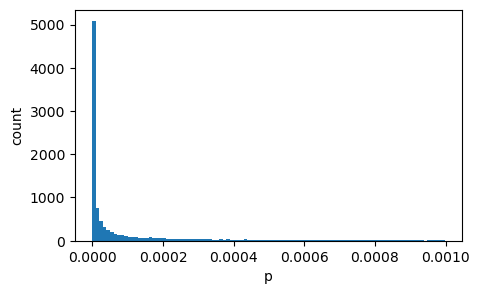

In [6]:
#plot obtained distribution
plt.figure(figsize=(5, 3))
plt.hist(p,bins=100)
plt.xlabel("p")
plt.ylabel("count")
plt.show()

In [7]:
#simulate sequencing
depths = np.random.choice(range(1000, 50000), size=10000, replace=True)
alt = np.random.binomial(depths, p)
data = pd.DataFrame({'DEPTH': depths, 'p':p,'ALT_DEPTH': alt})
data_mut = data[data['ALT_DEPTH'] > 0].copy()

data_mut['VAF'] = data_mut['ALT_DEPTH'] / data_mut['DEPTH']
data_mut["log_p"] = np.log10(data_mut['p'])

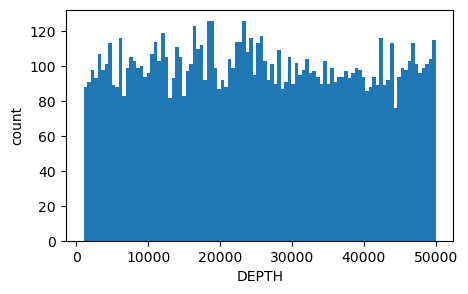

In [8]:
#plot obtained distribution
plt.figure(figsize=(5, 3))
plt.hist(data['DEPTH'],bins=100)
plt.xlabel("DEPTH")
plt.ylabel("count")
plt.show()

### Simulate non-duplex reads

In [9]:
# ND depth is correlated with duplex depth but noisy
np.random.seed(42)
nd_depth_factor = np.random.lognormal(
    mean=np.log(0.8),   # average ND depth ~1.5x duplex depth
    sigma=0.4,          # noise around this relationship
    size=len(data_mut)
)

data_mut["DEPTH_ND"] = (
    data_mut["DEPTH"] * nd_depth_factor
).round().astype(int)

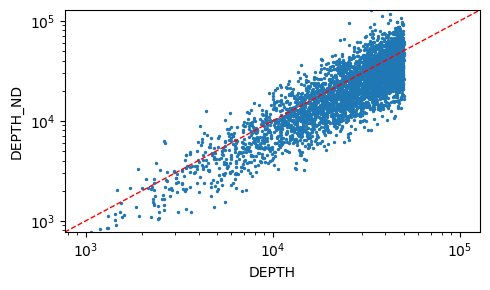

In [10]:
plot_scatter_with_diagonal(data_mut,'DEPTH','DEPTH_ND', plot_diag = True, log_scale_y=True, log_scale_x=True)

In [15]:
e_nd = 1e-5  # non-duplex error rate

# Effective VAF seen by non-duplex = true VAF + error rate contribution
p_nd_effective = data_mut['p'] + (1 - data_mut['p']) * e_nd

# Sample ND alt reads
data_mut['ALT_DEPTH_ND'] = np.random.binomial(
    data_mut['DEPTH_ND'].values,
    p_nd_effective.values
)

data_mut['VAF_ND'] = data_mut['ALT_DEPTH_ND'] / data_mut['DEPTH_ND']
data_mut['ALT_DEPTH_AM'] = data_mut['ALT_DEPTH'] + data_mut['ALT_DEPTH_ND']
data_mut['DEPTH_AM'] = data_mut['DEPTH'] + data_mut['DEPTH_ND']
data_mut['VAF_AM'] = data_mut['ALT_DEPTH_AM'] / data_mut['DEPTH_AM']
data_mut['VAF_pseudo'] = vaf_pseudocount(data_mut['ALT_DEPTH_AM'], data_mut['DEPTH_AM'], 1000, prior_vaf=1e-5)
data_mut["ND_bin"] = np.where(
    data_mut["ALT_DEPTH_ND"] == 0,
    0,
    np.where(data_mut["ALT_DEPTH_ND"] == 1, 1, 2)
)
data_mut.head()

,DEPTH,p,ALT_DEPTH,VAF,log_p,DEPTH_ND,ALT_DEPTH_ND,VAF_ND,ALT_DEPTH_AM,DEPTH_AM,VAF_AM,VAF_pseudo,ND_bin
1,48651,0.000635,23,0.000473,-3.197143,47476,37,0.000779,60,96127,0.000624,0.000618,2
2,45913,0.000085,3,0.000065,-4.072024,34754,1,0.000029,4,80667,0.000050,0.000049,1
7,46650,0.000292,18,0.000386,-3.535295,48357,11,0.000227,29,95007,0.000305,0.000302,2
8,39046,0.000025,1,0.000026,-4.595540,57444,2,0.000035,3,96490,0.000031,0.000031,2
9,47573,0.000068,3,0.000063,-4.167710,34656,4,0.000115,7,82229,0.000085,0.000084,2


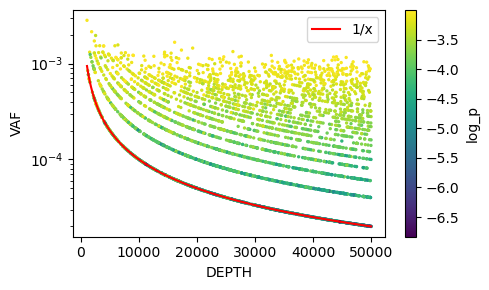

In [16]:
x = np.linspace(data_mut['DEPTH'].min(), data_mut['DEPTH'].max(), 1000)
plot_scatter_with_diagonal(data_mut,'DEPTH','VAF', plot_diag = False, log_scale_y=True, log_scale_x=False, color_col='log_p',extra_lines=[{'x': x, 'y': 1/x, 'label': '1/x', 'color': 'red', 'linestyle': '-'}])

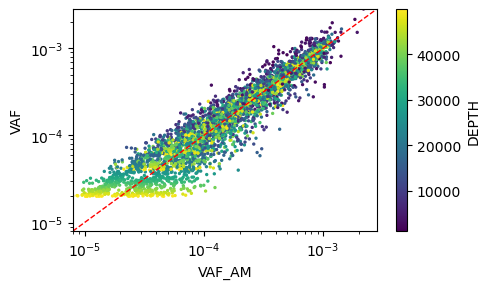

In [21]:
plot_scatter_with_diagonal(data_mut,'VAF_AM','VAF', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [17]:
data_mut["VAF_pseudo"] = vaf_pseudocount(data_mut['ALT_DEPTH'], data_mut['DEPTH'], 5000, prior_vaf=1e-5)
data_mut["VAF_AM_pseudo"] = vaf_pseudocount(data_mut['ALT_DEPTH_AM'], data_mut['DEPTH_AM'], 5000, prior_vaf=1e-5)
#data_mut["VAF_LB95"] = vaf_lower_bound(data_mut["ALT_DEPTH"], data_mut["DEPTH"])
data_mut.head()

,DEPTH,p,ALT_DEPTH,VAF,log_p,DEPTH_ND,ALT_DEPTH_ND,VAF_ND,ALT_DEPTH_AM,DEPTH_AM,VAF_AM,VAF_pseudo,ND_bin,VAF_AM_pseudo
1,48651,0.000635,23,0.000473,-3.197143,47476,37,0.000779,60,96127,0.000624,0.000430,2,0.000594
2,45913,0.000085,3,0.000065,-4.072024,34754,1,0.000029,4,80667,0.000050,0.000060,1,0.000047
7,46650,0.000292,18,0.000386,-3.535295,48357,11,0.000227,29,95007,0.000305,0.000349,2,0.000290
8,39046,0.000025,1,0.000026,-4.595540,57444,2,0.000035,3,96490,0.000031,0.000024,2,0.000030
9,47573,0.000068,3,0.000063,-4.167710,34656,4,0.000115,7,82229,0.000085,0.000058,2,0.000081


In [ ]:
print(data['p'].sum())

In [ ]:
print(f"{data["p"].median():.2e}")
print(f"{data["p"].mean():.2e}")

print(f"{data_mut['ALT_DEPTH'].sum()/data_mut['DEPTH'].sum():.2e}")
print(f"{data_mut['ALT_DEPTH'].sum()/data['DEPTH'].sum():.2e}")


In [ ]:
#plot_scatter_with_diagonal(data_mut,'VAF','VAF_LB95', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut,'VAF','VAF_pseudo', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut,'p','VAF', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
#plot_scatter_with_diagonal(data_mut,'p','VAF_LB95', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut,'p','VAF_pseudo', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
data_mut['VAF2p_ratio'] = data_mut['VAF']/data_mut['p']
data_mut['VAF2p_dif'] = data_mut['VAF']-data_mut['p']
data_mut['log_VAF2p_ratio'] = np.log10(data_mut['VAF']/data_mut['p'])
data_mut['VAF2p_ratio'].mean()

In [ ]:
#plot obtained distribution
plt.figure(figsize=(5, 3))
plt.hist(data_mut['VAF2p_dif'],bins=50)
plt.xlabel("VAF2p_dif")
plt.ylabel("count")
#plt.xscale('log')
plt.show()

In [ ]:
x = np.linspace(data_mut['DEPTH'].min(), data_mut['DEPTH'].max(), 1000)
from matplotlib.colors import TwoSlopeNorm

norm = TwoSlopeNorm(vmin=data_mut["log_VAF2p_ratio"].min(), vcenter=0, vmax=data_mut["log_VAF2p_ratio"].max())
plot_scatter_with_diagonal(
    data_mut, 'DEPTH', 'p',
    plot_diag=False,
    log_scale_y=True,
    log_scale_x=False,
    color_col='log_VAF2p_ratio',
    alpha=0.8,
    cmap='RdBu_r',
    norm=norm,
    extra_lines=[{'x': x, 'y': 1/x, 'label': '1/x', 'color': 'red', 'linestyle': '-'}]
)

In [ ]:
print(data_mut[(data_mut['DEPTH']>5000)&(data_mut['DEPTH']<10000)]['p'].sum())
print(data_mut[(data_mut['DEPTH']>45000)&(data_mut['DEPTH']<50000)]['p'].sum())

In [ ]:
x = np.linspace(data_mut['DEPTH'].min(), data_mut['DEPTH'].max(), 1000)
from matplotlib.colors import TwoSlopeNorm

norm = TwoSlopeNorm(vmin=data_mut["VAF2p_dif"].min(), vcenter=0, vmax=data_mut["VAF2p_dif"].max())
plot_scatter_with_diagonal(
    data_mut, 'DEPTH', 'p',
    plot_diag=False,
    log_scale_y=True,
    log_scale_x=False,
    color_col='VAF2p_dif',
    alpha=0.8,
    cmap='RdBu_r',
    norm=norm,
    extra_lines=[{'x': x, 'y': 1/x, 'label': '1/x', 'color': 'red', 'linestyle': '-'}]
)

In [ ]:
data_mut["ALT_DEPTH_bin"] = np.where(
    data_mut["ALT_DEPTH"] == 1,
    "1",
    np.where(data_mut["ALT_DEPTH"] == 2, "2", "3+"))

plot_scatter_with_diagonal(data_mut,'DEPTH','log_VAF2p_ratio', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col='ALT_DEPTH_bin',extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
plot_scatter_with_diagonal(data_mut,'DEPTH','VAF2p_dif', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col='ALT_DEPTH_bin',ylim=(-0.0008,0.0025),extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
x = np.linspace(data_mut['p'].min(), data_mut['p'].max(), 1000)
plot_scatter_with_diagonal(data_mut,'p','log_VAF2p_ratio', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col="DEPTH",extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
plot_scatter_with_diagonal(data_mut,'p','VAF2p_dif', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col="DEPTH",extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
plot_scatter_with_diagonal(data_mut,'log_VAF2p_ratio','VAF2p_dif', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col='ALT_DEPTH_bin')

In [ ]:
plot_scatter_with_diagonal(data_mut,'p','VAF_pseudo', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
data_mut['log_VAFpseudo2p_ratio'] = np.log10(data_mut['VAF_pseudo']/data_mut['p'])
data_mut['VAFpseudo2p_dif'] = data_mut['VAF_pseudo']-data_mut['p']

norm = TwoSlopeNorm(vmin=data_mut["log_VAFpseudo2p_ratio"].min(), vcenter=0, vmax=data_mut["log_VAFpseudo2p_ratio"].max())
x = np.linspace(data_mut['DEPTH'].min(), data_mut['DEPTH'].max(), 1000)
plot_scatter_with_diagonal(
    data_mut, 'DEPTH', 'p',
    plot_diag=False,
    log_scale_y=True,
    log_scale_x=False,
    color_col='log_VAFpseudo2p_ratio',
    alpha=0.8,
    cmap='RdBu_r',
    norm=norm,
    extra_lines=[{'x': x, 'y': 1/x, 'label': '1/x', 'color': 'red', 'linestyle': '-'}]
)

In [ ]:
plot_scatter_with_diagonal(data_mut,'DEPTH','log_VAFpseudo2p_ratio', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col='ALT_DEPTH_bin',extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
plot_scatter_with_diagonal(data_mut,'DEPTH','VAFpseudo2p_dif', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col='ALT_DEPTH_bin', ylim=(-0.0008,0.0025),extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
x = np.linspace(data_mut['p'].min(), data_mut['p'].max(), 1000)
plot_scatter_with_diagonal(data_mut,'p','log_VAFpseudo2p_ratio', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col="ALT_DEPTH_bin",extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
plot_scatter_with_diagonal(data_mut,'p','VAFpseudo2p_dif', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col="ALT_DEPTH_bin",ylim=(-0.0008,0.0025),extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
depth_bin_summary_simul = mutation_proportion_by_depth_bin(
    data_mut,
    data,
    mut_depth_col="DEPTH",
    all_depth_col="DEPTH"
)

depth_bin_summary_simul

In [ ]:
plt.figure(figsize=(4, 4))
plt.plot(
    depth_bin_summary_simul["depth_bin"].astype(str),
    depth_bin_summary_simul["proportion_mutated"],
    marker="o"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Proportion mutated")
plt.xlabel("Depth bin")
plt.tight_layout()
plt.show()

In [ ]:
depth_bin_summary_simul["depth_mid"] = [
    interval.mid for interval in depth_bin_summary_simul["depth_bin"]
]

depth_bin_summary_simul["p_hat"] = (
    -np.log(1 - depth_bin_summary_simul["proportion_mutated"])
    / depth_bin_summary_simul["depth_mid"]
)
depth_bin_summary_simul

In [ ]:
print(data["p"].mean())
print(depth_bin_summary_simul["p_hat"].mean())

In [ ]:
data_mut['VAFminusVAFAM'] = data_mut['VAF'] - data_mut['VAF_AM']

In [ ]:
x = np.linspace(data_mut['DEPTH'].min(), data_mut['DEPTH'].max(), 1000)

plot_scatter_with_diagonal(data_mut,'DEPTH','VAFminusVAFAM', plot_diag = False, log_scale_y=False, log_scale_x=True,color_col='ALT_DEPTH_bin',extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
plot_scatter_with_diagonal(data_mut,'VAF','VAF_AM', plot_diag = True, log_scale_y=True, log_scale_x=True,color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut,'VAF','VAF_ND', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut,'p','VAF_ND', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
def joint_neg_log_posterior(
    p,
    alt_d, depth_d,
    alt_nd, depth_nd,
    e_nd=1e-5,
    alpha=1,
    beta_prior=10000
):
    # Duplex likelihood
    ll_duplex = binom.logpmf(alt_d, depth_d, p)

    # Non-duplex likelihood with error
    p_nd_effective = p + (1 - p) * e_nd
    ll_nd = binom.logpmf(alt_nd, depth_nd, p_nd_effective)

    # Prior on true VAF
    log_prior = (alpha - 1) * np.log(p) + (beta_prior - 1) * np.log(1 - p)
    return -(ll_duplex + ll_nd + log_prior)

In [ ]:
def estimate_vaf_map(row, e_nd=1e-5, alpha=1, beta_prior=10000):
    res = minimize_scalar(
        joint_neg_log_posterior,
        bounds=(1e-9, 1.0),
        method="bounded",
        args=(
            row["ALT_DEPTH"],
            row["DEPTH"],
            row["ALT_DEPTH_ND"],
            row["DEPTH_ND"],
            e_nd,
            alpha,
            beta_prior
        )
    )
    return res.x

In [ ]:
def beta_params_from_mode_strength(mode_p, strength):
    alpha = 1 + mode_p * (strength - 2)
    beta_prior = 1 + (1 - mode_p) * (strength - 2)
    return alpha, beta_prior

In [ ]:
alpha, beta_prior = beta_params_from_mode_strength(
    mode_p=1e-5,
    strength=1000
)
print(alpha)
print(beta_prior)

In [ ]:
data_mut["VAF_mle"] = data_mut.apply(
    lambda row: estimate_vaf(row, e_nd=e_nd),
    axis=1
)

In [ ]:
data_mut["VAF_map"] = data_mut.apply(
    lambda row: estimate_vaf_map(
        row,
        e_nd=1e-5,
        alpha=alpha,
        beta_prior=beta_prior
    ),
    axis=1
)

In [ ]:
data_mut.head()

In [ ]:
data_mut[data_mut['DEPTH']<5000][['ALT_DEPTH','DEPTH','ALT_DEPTH_ND','DEPTH_ND','VAF', 'VAF_ND', 'VAF_pseudo','VAF_AM_pseudo','VAF_mle', 'VAF_map','p']].head(n=10)

In [ ]:
data_mut[data_mut['DEPTH']>40000][['ALT_DEPTH','DEPTH','ALT_DEPTH_ND','DEPTH_ND','VAF', 'VAF_ND','VAF_pseudo','VAF_AM_pseudo', 'VAF_mle', 'VAF_map','p']].head(n=10)

In [ ]:
plot_scatter_with_diagonal(data_mut,'p','VAF_pseudo', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut,'p','VAF_AM_pseudo', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut,'p','VAF_map', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut,'p','VAF_mle', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut,'p','VAF_AM', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut,'VAF_map','VAF_mle', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut,'VAF_map','VAF_pseudo', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut,'VAF_AM_pseudo','VAF_map', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut,'VAF','VAF_map', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut,'VAF_AM','VAF', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
x = np.linspace(data_mut['DEPTH'].min(), data_mut['DEPTH'].max(), 1000)
data_mut['VAF_mle_shrinkage'] = data_mut['VAF'] - data_mut['VAF_mle']
data_mut['VAF_map_shrinkage'] = data_mut['VAF'] - data_mut['VAF_map']

data_mut['VAF_pseudo_vs_p'] = data_mut['VAF_pseudo'] - data_mut['p']
data_mut['VAF_AM_pseudo_vs_p'] = data_mut['VAF_AM_pseudo'] - data_mut['p']
data_mut['VAF_mle_vs_p'] = data_mut['VAF_mle'] - data_mut['p']
data_mut['VAF_map_vs_p'] = data_mut['VAF_map'] - data_mut['p']
data_mut['VAF_vs_p'] = data_mut['VAF'] - data_mut['p']
data_mut['VAF_AM_vs_p'] = data_mut['VAF_AM'] - data_mut['p'] 


In [ ]:
plot_scatter_with_diagonal(data_mut,'DEPTH','VAF_vs_p', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col='ALT_DEPTH_bin',ylim=[-0.0008, 0.0025],extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
plot_scatter_with_diagonal(data_mut,'DEPTH','VAF_AM_vs_p', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col='ALT_DEPTH_bin',ylim=[-0.0008, 0.0025],extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
plot_scatter_with_diagonal(data_mut,'DEPTH','VAF_pseudo_vs_p', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col='ALT_DEPTH_bin',ylim=[-0.0008, 0.0025],extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
plot_scatter_with_diagonal(data_mut,'DEPTH','VAF_AM_pseudo_vs_p', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col='ALT_DEPTH_bin',ylim=[-0.0008, 0.0025],extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
plot_scatter_with_diagonal(data_mut,'DEPTH','VAF_mle_vs_p', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col='ALT_DEPTH_bin',ylim=[-0.0008, 0.0025],extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
plot_scatter_with_diagonal(data_mut,'DEPTH','VAF_map_vs_p', plot_diag = False, log_scale_y=False, log_scale_x=False,color_col='ALT_DEPTH_bin',ylim=[-0.0008, 0.0025],extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

### SELECT weight

In [ ]:
weights = [0,1000, 2000, 3000, 4000, 5000]
prior_vafs = [1e-4, 1e-5, 1e-7, 1e-6]


for weight in weights:
    for prior_vaf in prior_vafs:
        col = f"VAF_PSEUDO_AM_w{weight}_p{prior_vaf:.0e}"
        data_mut[col] = vaf_pseudocount(data_mut["ALT_DEPTH_AM"],data_mut["DEPTH_AM"], weight, prior_vaf=prior_vaf)
        col = f"VAF_PSEUDO_w{weight}_p{prior_vaf:.0e}"
        data_mut[col] = vaf_pseudocount(data_mut["ALT_DEPTH"],data_mut["DEPTH"], weight, prior_vaf=prior_vaf)
    #col = f"VAF_PSEUDO_ND_w{weight}"
    #dg[col] = vaf_pseudocount_nd(dg["ALT_DEPTH_AM"],dg["DEPTH_AM"], weight, prior_vaf=dg["VAF_ND"])

In [ ]:
data_mut['VAFpseudominusVAF_AM'] = data_mut['VAF_PSEUDO_w5000_p1e-05'] - data_mut['VAF_AM'] 
plot_scatter_with_diagonal(data_mut,'DEPTH','VAFpseudominusVAF_AM', plot_diag = False, log_scale_y=False, log_scale_x=False, color_col="ND_bin",extra_lines=[{'x': x, 'y': np.zeros_like(x), 'color': 'black', 'linestyle': '-'}])

In [ ]:
weights = [0,1000, 2000, 3000, 4000, 5000]

dist_df = calc_vaf_distance_summary(
    data_mut,
    weights=weights,
    vaf_col="VAF",
    target_col="VAF_AM",
    pseudo_prefix="VAF_PSEUDO",
    prior="p1e-05",
    depth_col="DEPTH",
    depth_quantile=0.2,
    large_clone_threshold=1e-2,
)


In [ ]:
dist_df.head()

In [ ]:
fig, ax = plot_vaf_distance_summary(
    dist_df,
    log_dist=True,
    use_mean=False,
    log_y=False
)

In [ ]:
plot_scatter_with_diagonal(data_mut[data_mut['DEPTH'] < dist_df['depth_cutoff'][1]],'VAF_AM','VAF', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

In [ ]:
plot_scatter_with_diagonal(data_mut[data_mut['DEPTH'] < dist_df['depth_cutoff'][1]],'VAF_AM','VAF_PSEUDO_w5000_p1e-05', plot_diag = True, log_scale_y=True, log_scale_x=True, color_col='DEPTH')

# Non-hierarchical regression

In [ ]:
individual = 'SP005_B1'
dh = dg[dg['INDIVIDUAL_ID'] == individual]

In [ ]:
model_non_hierarchical = bmb.Model("p(ALT_DEPTH, DEPTH) ~ 0 + MUTATION_ID", dh, family="binomial")
model_non_hierarchical

In [ ]:
idata_non_hierarchical = model_non_hierarchical.fit(random_seed=1234, chains=1, draws=500, hotwarmup=500)

In [ ]:
az.plot_trace(idata_non_hierarchical, coords={"MUTATION_ID_dim": idata_non_hierarchical.posterior.MUTATION_ID_dim[:8]})
plt.tight_layout()
plt.show()

In [ ]:
pc = azp.plot_forest(
    idata_non_hierarchical, 
    var_names=["MUTATION_ID"], 
    # coords={"MUTATION_ID_dim": idata_non_hierarchical.posterior.MUTATION_ID_dim[:30]},
    figure_kwargs={"figsize": (8, 20)}
)

plt.tight_layout()
plt.show()

# Hierarchical regression

In [ ]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=0, sigma=1),
    "1|MUTATION_ID": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=1))
}

In [ ]:
model_hierarchical = bmb.Model("p(ALT_DEPTH, DEPTH) ~ 1 + (1|MUTATION_ID)", dh, family="binomial", priors=priors)
model_hierarchical

In [ ]:
idata_hierarchical = model_hierarchical.fit(random_seed=1234, chains=1, draws=500, tune=500)

In [ ]:
idata_prior = model_hierarchical.prior_predictive()
prior = idata_prior.prior_predictive["p(ALT_DEPTH, DEPTH)"]

In [ ]:
az.plot_trace(idata_hierarchical, coords={"MUTATION_ID__factor_dim": idata_hierarchical.posterior.MUTATION_ID__factor_dim[:8]})
plt.tight_layout()
plt.show()


# Compare the two models

In [ ]:
model_non_hierarchical.predict(idata_non_hierarchical)
model_hierarchical.predict(idata_hierarchical)

p_hierarchical = idata_hierarchical.posterior["p"].mean(dim=["chain", "draw"]).values
p_non_hierarchical = idata_non_hierarchical.posterior["p"].mean(dim=["chain", "draw"]).values

plt.scatter(p_hierarchical, p_non_hierarchical)
plt.xlabel("Hierarchical")
plt.ylabel("Non-Hierarchical")
plt.title("Comparison of Posterior Predictive Distributions")
plt.show()

In [ ]:
_, ax = plt.subplots(figsize = (8, 8))

# Add vertical line for the global probability of hitting
ax.axvline(x=(dh["ALT_DEPTH"] / dh["DEPTH"]).mean(), ls="--", color="black", alpha=0.5)

# Create forestplot with ArviZ, only for the mean.
az.plot_forest(
    [idata_non_hierarchical, idata_hierarchical],
    var_names=["p"],
    # combined=True,
    # colors=["#666666", "red"],
    # linewidth=2.6,
    # markersize=8,
    # ax=ax
)

# Create custom y axis tick labels
ylabels = [f"ALT_DEPTH: {round(alt_depth)}, DEPTH: {round(depth)}" for alt_depth, depth in zip(dh["ALT_DEPTH"].values, dh["DEPTH"].values)]
ylabels = list(reversed(ylabels))

# Put the labels for the y axis in the mid of the original location of the tick marks.
ax.set_yticklabels(ylabels, ha="right")

# Create legend
handles = [
    Patch(label="Non-hierarchical", facecolor="#666666"),
    Patch(label="Hierarchical", facecolor="red"),
    Line2D([0], [0], label="Mean probability", ls="--", color="black", alpha=0.5)
]

legend = ax.legend(handles=handles, loc=4, fontsize=14, frameon=True, framealpha=0.8);

# Prior tuning

In [ ]:
def fit_with_priors(intercept_sigma, group_sigma_scale, label=""):
    """Fit hierarchical model with custom prior specifications."""
    priors = {
        "Intercept": bmb.Prior("Normal", mu=0, sigma=intercept_sigma),
        "1|MUTATION_ID": bmb.Prior("Normal", mu=0, sigma=bmb.Prior("HalfNormal", sigma=group_sigma_scale))
    }
    model = bmb.Model("p(ALT_DEPTH, DEPTH) ~ 1 + (1|MUTATION_ID)", dh, family="binomial", priors=priors)
    idata = model.fit(random_seed=1234, chains=1, draws=500, tune=500, progressbar=False)
    return idata, model, label

# Test different prior configurations
prior_configs = [
    (1.0, 1.0, "Current: σ_int=1.0, σ_group=1.0"),
    (2.0, 2.0, "Weakly informative: σ_int=2.0, σ_group=2.0"),
    (3.0, 3.0, "Very weak: σ_int=3.0, σ_group=3.0"),
    (0.5, 0.5, "Tighter: σ_int=0.5, σ_group=0.5"),
    (1.0, 10.0, "Mixed: σ_int=1.0, σ_group=10.0")
]

results = {}
models = {}
for intercept_sigma, group_sigma, label in prior_configs:
    print(f"Fitting: {label}")
    idata, model, _ = fit_with_priors(intercept_sigma, group_sigma, label)
    results[label] = idata
    models[label] = model

In [ ]:
# Compare Intercept posteriors across prior configurations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, idata in results.items():
    intercept_draws = idata.posterior["Intercept"].values.flatten()
    axes[0].hist(intercept_draws, alpha=0.5, label=label, bins=30)

axes[0].set_xlabel("Intercept")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Intercept Posterior Across Prior Configurations")
axes[0].legend(fontsize=9)

# Compare group-level standard deviation posteriors
for label, idata in results.items():
    sigma_draws = idata.posterior["1|MUTATION_ID_sigma"].values.flatten()
    axes[1].hist(sigma_draws, alpha=0.5, label=label, bins=30)

axes[1].set_xlabel("1|MUTATION_ID sigma")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Group-level Std Dev Posterior Across Prior Configurations")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# Select best prior configuration and fit final model
best_config = "Weakly informative: σ_int=2.0, σ_group=2.0"  # Change this to your preferred config
best_config = "Very weak: σ_int=3.0, σ_group=3.0"
best_config = "Mixed: σ_int=1.0, σ_group=10.0"
idata_best = results[best_config]
model_best = models[best_config]

print(f"Selected prior configuration: {best_config}")
print("\nPosterior Summary:")
az.summary(idata_best, var_names=["Intercept", "1|MUTATION_ID_sigma"])

In [ ]:
model_non_hierarchical.predict(idata_non_hierarchical)
model_best.predict(idata_best)

p_best = idata_best.posterior["p"].mean(dim=["chain", "draw"]).values
p_non_hierarchical = idata_non_hierarchical.posterior["p"].mean(dim=["chain", "draw"]).values

plt.scatter(p_best, p_non_hierarchical)
plt.xlabel("Best Model")
plt.ylabel("Non-Hierarchical")
plt.title("Comparison of Posterior Predictive Distributions")
plt.show()
